# AIR Phase 3 Notebook

Use this notebook for your own run. The setup cells, file checks, report readers, and packaging commands are already in place. Fill the TODO blocks where the retrieval representation, hybrid merge, reranking text, or fusion logic is part of the project work.


# Stage 0

The prepared ABO-Home catalog is included in the project folder. Run the check below before using the catalog in the later stages.


In [ ]:
# Extract the fixed image subset once, then run the catalog check.
from pathlib import Path
import zipfile

image_zip = Path("data/AIR_Phase3_stage1_images.zip")
image_root = Path("data/raw/images/small")
if image_zip.exists() and not any(image_root.rglob("*.jpg")):
    print("extracting", image_zip)
    with zipfile.ZipFile(image_zip) as zf:
        zf.extractall(".")

!python src/tests.py --stage 0 --catalog data/catalog_subset.parquet


Stage 0 acceptance tests:
  [PASS] every row has a non-empty product_id
  [PASS] product_id is unique
  [PASS] every row has non-empty title
  [PASS] every row has non-empty product_text
  [PASS] every row has non-empty image_path
  [PASS] every local image_path exists
  [PASS] subset contains multiple product types
  [PASS] product_text contains metadata beyond the title

8 passed, 0 failed, 0 skipped
ALL PASSED
Loadable by pandas.read_parquet: True (2000 rows)


# Stage 1


# Stage 1 — Single-Vector Multimodal Dense + SPLADE++ Sparse Embeddings & Indexes

This notebook builds the first-stage search representation for the ABO-Home-2K
catalog produced in Stage 0.

For each product it creates:

1. **one single-vector multimodal dense embedding** from the combined
   `{"text": product_text, "image": image_path}` input (no manual text/image
   averaging — the model fuses modalities internally);
2. **one SPLADE++-style sparse embedding** from `product_text`;
3. **searchable dense (FAISS) and sparse (SciPy CSR) indexes**.

### Required outputs
```
artifacts/embeddings/product_dense.npy
artifacts/embeddings/product_sparse.jsonl
artifacts/embeddings/product_ids.txt
artifacts/index/dense_index.faiss
artifacts/index/sparse_index.npz
artifacts/index/index_manifest.json
reports/indexing_summary.md
```

`product_ids.txt` is the shared **product-ID mapping**: FAISS row `i` ↔ CSR row
`i` ↔ `product_ids.txt` line `i` ↔ `product_dense.npy` row `i`.

### How to run on Colab
1. Put your Stage 1 inputs in a Google Drive folder named
   **`AIR_Phase3_stage1_input`** containing:
   - `catalog_subset.parquet`
   - the product images as a **`.zip`** (e.g. `raw.zip` of `data/raw`) or a folder tree.
2. Use a **GPU runtime** (the dense VLM needs ~8 GB VRAM; a T4 is fine with
   the batch size you select for the run).
3. Run top to bottom. The notebook mounts Drive, copies the inputs to local
   disk (`/content`), unzips the images there for fast reads, then writes all
   artifacts under `artifacts/` and `reports/`.


## 0. Install dependencies

In [ ]:
# Install the retrieval and indexing runtime from pyproject.toml.
import os
import subprocess
import sys

try:
    import tomllib
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tomli"])
    import tomli as tomllib

PROJECT_FILE = "pyproject.toml"
with open(PROJECT_FILE, "rb") as f:
    project_cfg = tomllib.load(f)

deps = list(project_cfg["project"].get("dependencies", []))
deps += list(project_cfg["project"].get("optional-dependencies", {}).get("stage1-gpu", []))
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *deps])
print("dependencies installed from", PROJECT_FILE)

!pip uninstall torchaudio  # This is because of some errors in Colab


dependencies installed from pyproject.toml


## 1. Mount Drive, stage inputs onto local disk & resolve images


here is the link to the raw data (output of stage 0):
https://drive.google.com/drive/folders/1Z_kG20b3snyV8nEszNdpDiq4wxmKlL0C?usp=sharing

In [ ]:
import os, json, time, glob, shutil, zipfile
import numpy as np
import pandas as pd

# ----- mount Google Drive -----
from google.colab import drive
# drive.mount("/content/drive")

# TODO: set the Drive folder that contains the Stage 1 catalog and images.
DRIVE_INPUT = "/content/data"
WORK        = "/content/stage1_input"
os.makedirs(WORK, exist_ok=True)

# ----- output locations -----
EMB_DIR    = "artifacts/embeddings"
INDEX_DIR  = "artifacts/index"
REPORT_DIR = "reports"
for d in (EMB_DIR, INDEX_DIR, REPORT_DIR):
    os.makedirs(d, exist_ok=True)

DENSE_NPY    = f"{EMB_DIR}/product_dense.npy"
SPARSE_JSONL = f"{EMB_DIR}/product_sparse.jsonl"
IDS_TXT      = f"{EMB_DIR}/product_ids.txt"
DENSE_INDEX  = f"{INDEX_DIR}/dense_index.faiss"
SPARSE_INDEX = f"{INDEX_DIR}/sparse_index.npz"
MANIFEST     = f"{INDEX_DIR}/index_manifest.json"
SUMMARY      = f"{REPORT_DIR}/indexing_summary.md"

# TODO: choose the dense and sparse encoders used for this run.
DENSE_MODEL  = "Qwen/Qwen3-VL-Embedding-2B"
SPARSE_MODEL = "prithivida/Splade_PP_en_v2"

# TODO: fill the run knobs before executing the embedding cells.
DENSE_BATCH_SIZE  = 2
DENSE_CHUNK       = 200
SPARSE_BATCH_SIZE = 16
SPARSE_MAX_LEN    = 256
SPARSE_TOP_N      = 128
DENSE_NORMALIZE   = True


print("Drive input:", DRIVE_INPUT)
print("dense:", DENSE_MODEL, "| sparse:", SPARSE_MODEL)


Drive input: /content/data
dense: Qwen/Qwen3-VL-Embedding-2B | sparse: prithivida/Splade_PP_en_v2


In [ ]:
# TODO: verify the catalog and image tree resolve correctly for your input folder.
# ----- unzip any archives in the Drive folder (e.g. raw.zip) to local disk --
os.makedirs(WORK, exist_ok=True)
zips = sorted(glob.glob(os.path.join(DRIVE_INPUT, "*.zip")))
for z in zips:
    local_zip = os.path.join(WORK, os.path.basename(z))
    print("copying zip:", z)
    shutil.copyfile(z, local_zip)
    print("unzipping", os.path.basename(z), "...")
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall(WORK)
if not zips:
    print("no .zip in Drive folder; will read images directly from Drive (slower)")

def _find(name, *roots):
    """Find a file by name directly under, or anywhere within, the given roots."""
    for root in roots:
        direct = os.path.join(root, name)
        if os.path.exists(direct):
            return direct
        hits = glob.glob(os.path.join(root, "**", name), recursive=True)
        if hits:
            return sorted(hits)[0]
    return None

# ----- locate catalog_subset.parquet (Drive folder, then unzipped tree) ----
src_parquet = _find("catalog_subset.parquet", DRIVE_INPUT, WORK)
assert src_parquet, ("catalog_subset.parquet not found in " + DRIVE_INPUT +
                     " or inside any uploaded zip.")
CATALOG_PATH = os.path.join(WORK, "catalog_subset.parquet")
if os.path.abspath(src_parquet) != os.path.abspath(CATALOG_PATH):
    shutil.copyfile(src_parquet, CATALOG_PATH)
print("catalog:", src_parquet)

# ----- build a basename -> path index over the images (layout-agnostic) ----
# Works whether raw.zip expands to data/raw/images/small/... or raw/images/...
IMAGES_BASE = WORK if zips else DRIVE_INPUT
print("indexing image files under", IMAGES_BASE, "...")
IMAGE_INDEX = {}
for root, _, files in os.walk(IMAGES_BASE):
    for fn in files:
        if fn.lower().endswith((".jpg", ".jpeg", ".png")):
            IMAGE_INDEX.setdefault(fn, os.path.join(root, fn))
print("images indexed:", len(IMAGE_INDEX))

def resolve_image(path):
    cand = os.path.join(IMAGES_BASE, path)        # fast path if tree is already present
    if os.path.exists(cand):
        return cand
    if os.path.isabs(path) and os.path.exists(path):
        return path
    return IMAGE_INDEX.get(os.path.basename(path))   # robust: match by filename

# ----- load catalog & verify required columns -------------
catalog = pd.read_parquet(CATALOG_PATH)
REQUIRED = ["product_id", "title", "product_text", "image_path"]
missing = [c for c in REQUIRED if c not in catalog.columns]
assert not missing, f"catalog missing required columns: {missing}"
print(f"catalog rows: {len(catalog)}")

catalog["resolved_image"] = catalog["image_path"].map(resolve_image)
n_missing_img = int(catalog["resolved_image"].isna().sum())
print(f"images resolved: {len(catalog) - n_missing_img}/{len(catalog)} "
      f"(missing: {n_missing_img})")
assert n_missing_img == 0, "Some images not found - check raw.zip contents."

# Stable ordering: product_ids.txt line i <-> product_dense.npy row i
product_ids   = catalog["product_id"].tolist()
product_texts = catalog["product_text"].tolist()
image_paths   = catalog["resolved_image"].tolist()

copying zip: /content/data/AIR_Phase3_stage1_images.zip
unzipping AIR_Phase3_stage1_images.zip ...
catalog: /content/data/catalog_subset.parquet
indexing image files under /content/stage1_input ...
images indexed: 5310
catalog rows: 2000
images resolved: 2000/2000 (missing: 0)


## 2. Dense multimodal embeddings

The dense vector is produced **directly** from the combined
`{"text": product_text, "image": image_path}` object via `encode_document`
(falling back to `encode`). We never encode text and image separately and merge
them. Embeddings are **checkpointed every `DENSE_CHUNK` products** so a Colab
disconnect can resume instead of restarting, and the final `.npy` is cached so
later retrieval runs never recompute it.

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu"
print("device:", DEVICE, "|", GPU_NAME)

# TODO: load DENSE_MODEL as a SentenceTransformer on DEVICE. Use float16 on
# CUDA if it is supported, and keep a fallback path for default dtype. Set
# DENSE_LOAD_CFG to describe the load path that actually worked.
dtype = torch.float16 if DEVICE == 'cuda' else torch.float32
dense_model = SentenceTransformer(DENSE_MODEL, model_kwargs={'torch_dtype': dtype})
dense_model.to(DEVICE)
DENSE_LOAD_CFG = f'device={DEVICE}, torch_dtype={dtype}'

print("loaded:", DENSE_MODEL)


device: cuda | Tesla T4


modules.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/770 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

loaded: Qwen/Qwen3-VL-Embedding-2B


In [ ]:
def l2_normalize(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms

def encode_documents(inputs, batch_size):
    """Encode product dictionaries into one dense vector per product."""
    kw = dict(batch_size=batch_size, show_progress_bar=False,
              convert_to_numpy=True, normalize_embeddings=DENSE_NORMALIZE)
    fn = getattr(dense_model, "encode_document", None)

    # TODO: call encode_document when the model exposes it, and fall back to
    # dense_model.encode otherwise. Return a float32 NumPy array with one row
    # per product input.
    if fn is not None:
        return fn(inputs, **kw).astype(np.float32)
    return dense_model.encode(inputs, **kw).astype(np.float32)

# Build the multimodal product inputs: one dict per product.
product_inputs = [{"text": t, "image": p}
                  for t, p in zip(product_texts, image_paths)]

# Smoke test on 2 products before the full run.
_smoke = encode_documents(product_inputs[:2], batch_size=2)
print("smoke embedding shape:", _smoke.shape)
DENSE_DIM = int(_smoke.shape[1])
print("dense dimension:", DENSE_DIM)


smoke embedding shape: (2, 2048)
dense dimension: 2048


In [ ]:
from tqdm.auto import tqdm

def build_dense(inputs, out_npy, ids_txt, chunk, batch_size):
    # Cache: never recompute embeddings on later runs.
    if os.path.exists(out_npy) and os.path.exists(ids_txt):
        print("dense cache hit -> loading", out_npy)
        return np.load(out_npy)

    part_npy, part_cnt = out_npy + ".part.npy", out_npy + ".part.cnt"
    parts, done = [], 0
    if os.path.exists(part_npy) and os.path.exists(part_cnt):
        parts.append(np.load(part_npy))
        done = int(open(part_cnt).read().strip())
        print(f"resuming dense from {done}/{len(inputs)}")

    for s in tqdm(range(done, len(inputs), chunk), desc="dense"):
        # TODO: encode inputs[s:s + chunk], normalize the chunk when requested,
        # append it to parts, and checkpoint the partial matrix and count.
        chunk_dense = encode_documents(inputs[s:s + chunk], batch_size)
        if DENSE_NORMALIZE:
            chunk_dense = l2_normalize(chunk_dense)
        parts.append(chunk_dense)
        done = s + chunk
        np.save(part_npy, np.vstack(parts))
        with open(part_cnt, 'w') as f:
            f.write(str(done))

    dense = np.vstack(parts).astype(np.float32)
    np.save(out_npy, dense)
    # IDs written in the exact catalog row order: row i <-> line i.
    with open(ids_txt, "w") as f:
        f.write("\n".join(product_ids) + "\n")
    for p in (part_npy, part_cnt):
        if os.path.exists(p):
            os.remove(p)
    return dense

t0 = time.time()
product_dense = build_dense(product_inputs, DENSE_NPY, IDS_TXT,
                            DENSE_CHUNK, DENSE_BATCH_SIZE)
DENSE_MINUTES = (time.time() - t0) / 60
print("dense matrix:", product_dense.shape, "| minutes:", round(DENSE_MINUTES, 1))

assert product_dense.shape[0] == len(catalog), "one dense vector per product"
DENSE_DIM = int(product_dense.shape[1])
_norms = np.linalg.norm(product_dense, axis=1)
print("norm mean/min/max: %.4f / %.4f / %.4f" %
      (_norms.mean(), _norms.min(), _norms.max()))


dense:   0%|          | 0/10 [00:00<?, ?it/s]

dense matrix: (2000, 2048) | minutes: 3.0
norm mean/min/max: 1.0000 / 1.0000 / 1.0000


## 3. Sparse SPLADE++ embeddings

SPLADE weight per vocab term = `max_t log(1 + relu(logits_t))` over the
sequence (attention-masked). We keep the **top-`SPARSE_TOP_N`** non-zero dims
per product and store them as `{product_id, indices, values}` — never a dense
30k array.

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

sp_tokenizer = AutoTokenizer.from_pretrained(SPARSE_MODEL)
sp_model = AutoModelForMaskedLM.from_pretrained(SPARSE_MODEL).to(DEVICE).eval()
VOCAB_SIZE = int(sp_model.config.vocab_size)
print("loaded sparse model:", SPARSE_MODEL, "| vocab:", VOCAB_SIZE)

@torch.no_grad()
def splade_encode_batch(texts, top_n):
    enc = sp_tokenizer(texts, padding=True, truncation=True,
                       max_length=SPARSE_MAX_LEN, return_tensors="pt").to(DEVICE)

    # TODO: run the masked-LM, compute SPLADE weights, apply the attention
    # mask, keep each row's top-N non-zero dimensions, and return a list of
    # (indices, values) arrays ordered by descending weight.
    outputs = sp_model(**enc)
    weights = torch.log(1 + torch.relu(outputs.logits))
    weights = weights * enc['attention_mask'].unsqueeze(-1)
    term_weights = torch.max(weights, dim=1)[0]
    results = []
    for i in range(term_weights.shape[0]):
        row_weights = term_weights[i]
        k = min(top_n, (row_weights > 0).sum().item())
        if k == 0:
            results.append((np.array([], dtype=np.int64), np.array([], dtype=np.float32)))
        else:
            topk = torch.topk(row_weights, k)
            results.append((topk.indices.cpu().numpy(), topk.values.cpu().numpy()))
    return results


config.json:   0%|          | 0.00/848 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/497 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

loaded sparse model: prithivida/Splade_PP_en_v2 | vocab: 30522


In [ ]:
import scipy.sparse as sp

def build_sparse(texts, jsonl_path, npz_path, batch_size, top_n):
    if os.path.exists(jsonl_path) and os.path.exists(npz_path):
        print("sparse cache hit -> loading", npz_path)
        return sp.load_npz(npz_path), None

    rows, cols, data, nnz_counts, failures = [], [], [], [], 0
    with open(jsonl_path, "w") as fout:
        for s in tqdm(range(0, len(texts), batch_size), desc="sparse"):
            batch = texts[s:s + batch_size]
            try:
                # TODO: encode this text batch with splade_encode_batch.
                encoded = splade_encode_batch(batch, top_n)
            except Exception as e:
                print("sparse batch failed at", s, ":", e)
                failures += len(batch)
                for j in range(len(batch)):
                    fout.write(json.dumps({"product_id": product_ids[s + j],
                                           "indices": [], "values": [],
                                           "error": str(e)}) + "\n")
                continue
            for j, (idx, val) in enumerate(encoded):
                i = s + j
                # TODO: write the product's sparse JSONL row and add the row,
                # column, value triples used to build the CSR matrix.
                fout.write(json.dumps({'product_id': product_ids[i], 'indices': idx.tolist(), 'values': val.tolist()}) + '\n')
                rows.extend([i] * len(idx))
                cols.extend(idx.tolist())
                data.extend(val.tolist())
                nnz_counts.append(len(idx))

    matrix = sp.csr_matrix((data, (rows, cols)),
                           shape=(len(texts), VOCAB_SIZE), dtype=np.float32)
    sp.save_npz(npz_path, matrix)
    stats = {"avg_nnz": float(np.mean(nnz_counts)) if nnz_counts else 0.0,
             "min_nnz": int(np.min(nnz_counts)) if nnz_counts else 0,
             "max_nnz": int(np.max(nnz_counts)) if nnz_counts else 0,
             "failures": failures}
    return matrix, stats

product_sparse, SPARSE_STATS = build_sparse(
    product_texts, SPARSE_JSONL, SPARSE_INDEX, SPARSE_BATCH_SIZE, SPARSE_TOP_N)
if SPARSE_STATS is None:
    nnz = product_sparse.getnnz(axis=1)
    SPARSE_STATS = {"avg_nnz": float(nnz.mean()), "min_nnz": int(nnz.min()),
                    "max_nnz": int(nnz.max()), "failures": 0}
print("sparse matrix:", product_sparse.shape, "| stats:", SPARSE_STATS)
assert 0 < SPARSE_STATS["avg_nnz"] < VOCAB_SIZE, "avg nnz must be >0 and < vocab"


sparse:   0%|          | 0/125 [00:00<?, ?it/s]

sparse matrix: (2000, 30522) | stats: {'avg_nnz': 120.4345, 'min_nnz': 46, 'max_nnz': 128, 'failures': 0}


## 4. Build indexes — Option B: FAISS dense + CSR sparse + manifest

In [ ]:
import faiss

# Dense: inner product over L2-normalized vectors == cosine similarity.
# TODO: create an IndexFlatIP with DENSE_DIM, add product_dense, and save it
# to DENSE_INDEX.
dense_index = faiss.IndexFlatIP(DENSE_DIM)
dense_index.add(product_dense)
faiss.write_index(dense_index, DENSE_INDEX)

print("dense index:", dense_index.ntotal, "vectors, dim", DENSE_DIM)

# Sparse index is already saved as CSR .npz. Search = dot product.
def sparse_search(query_indices, query_values, top_k=...):
    # TODO: build the query vector, multiply by product_sparse, and return the
    # top_k row indices with scores sorted from highest to lowest.
    q_vec = sp.csr_matrix((query_values, (np.zeros_like(query_indices), query_indices)), shape=(1, VOCAB_SIZE), dtype=np.float32)
    scores = q_vec.dot(product_sparse.T).toarray()[0]
    top_idx = np.argsort(scores)[::-1][:top_k]
    return [(int(i), float(scores[i])) for i in top_idx if scores[i] > 0]

def dense_search(query_vec, top_k=...):
    # TODO: normalize the query vector, search dense_index, and return row
    # indices with similarity scores.
    q_vec = l2_normalize(np.array([query_vec], dtype=np.float32)) if DENSE_NORMALIZE else np.array([query_vec], dtype=np.float32)
    scores, indices = dense_index.search(q_vec, top_k)
    return list(zip(indices[0].tolist(), scores[0].tolist()))


dense index: 2000 vectors, dim 2048


In [ ]:
# TODO: fill the manifest with the model choices, dimensions, storage format,
# and run settings that were actually used above.
manifest = {
    "num_products": int(len(catalog)),
    "dense_model": DENSE_MODEL,
    "dense_input_format": "multimodal_dict_text_image",
    "dense_embedding_policy": "single_vector_from_combined_text_image_input",
    "manual_text_image_vector_mixing": False,
    "dense_encode_method": "encode_document",
    "dense_load_config": DENSE_LOAD_CFG,
    "dense_batch_size": DENSE_BATCH_SIZE,
    "sparse_model": SPARSE_MODEL,
    "sparse_max_len": SPARSE_MAX_LEN,
    "dense_dimension": DENSE_DIM,
    "sparse_top_n": SPARSE_TOP_N,
    "sparse_vocab_size": VOCAB_SIZE,
    "vector_store": "faiss_plus_csr",
    "similarity": "cosine (inner product on normalized vectors)",
    "id_mapping_file": IDS_TXT,
    "runtime": GPU_NAME,
    "created_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
}
with open(MANIFEST, "w") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))


{
  "num_products": 2000,
  "dense_model": "Qwen/Qwen3-VL-Embedding-2B",
  "dense_input_format": "multimodal_dict_text_image",
  "dense_embedding_policy": "single_vector_from_combined_text_image_input",
  "manual_text_image_vector_mixing": false,
  "dense_encode_method": "encode_document",
  "dense_load_config": "device=cuda, torch_dtype=torch.float16",
  "dense_batch_size": 2,
  "sparse_model": "prithivida/Splade_PP_en_v2",
  "sparse_max_len": 256,
  "dense_dimension": 2048,
  "sparse_top_n": 128,
  "sparse_vocab_size": 30522,
  "vector_store": "faiss_plus_csr",
  "similarity": "cosine (inner product on normalized vectors)",
  "id_mapping_file": "artifacts/embeddings/product_ids.txt",
  "runtime": "Tesla T4",
  "created_at": "2026-07-26T17:37:37Z"
}


## 5. Sanity-check searches

Self-retrieval probes: a product's own image / text / title should rank the
product itself at (or very near) the top.

In [ ]:
# TODO: choose how many hits to inspect in the self-retrieval checks.
SANITY_TOP_K = 10

def encode_query_dense(q):
    fn = getattr(dense_model, "encode_query", None)
    kw = dict(convert_to_numpy=True, normalize_embeddings=DENSE_NORMALIZE)

    # TODO: encode text, image path, and {"text", "image"} query inputs with
    # the same dense model used for products. Prefer encode_query when it is
    # available, and return a float32 vector.
    from PIL import Image
    if isinstance(q, str):
        if q.lower().endswith(('.jpg', '.jpeg', '.png')) and os.path.exists(q):
            parsed_q = Image.open(q)
        else:
            parsed_q = q
    elif isinstance(q, dict):
        parsed_q = dict(q)
        if "image" in parsed_q and isinstance(parsed_q["image"], str):
            parsed_q["image"] = Image.open(parsed_q["image"])
    else:
        parsed_q = q

    if fn is not None:
        res = fn([parsed_q], **kw)
    else:
        res = dense_model.encode([parsed_q], **kw)

    return res[0].astype(np.float32) if len(res.shape) > 1 else res.astype(np.float32)

def _self_rank(res, target):
    return next((k for k, (i, _) in enumerate(res) if i == target), None)

SANITY = []
probe_rows = [0, len(catalog) // 2, len(catalog) - 1]

# (a) dense image-only self-retrieval
r = probe_rows[0]
res = dense_search(encode_query_dense(image_paths[r]), top_k=SANITY_TOP_K)
SANITY.append({"kind": "DENSE image-query", "product": product_ids[r],
               "rank": _self_rank(res, r),
               "top": [product_ids[i] for i, _ in res][:3]})

# (b) dense text-only self-retrieval
r = probe_rows[1]
res = dense_search(encode_query_dense(product_texts[r]), top_k=SANITY_TOP_K)
SANITY.append({"kind": "DENSE text-query", "product": product_ids[r],
               "rank": _self_rank(res, r),
               "top": [product_ids[i] for i, _ in res][:3]})

# (c) dense image+text combined query
r = probe_rows[2]
q = encode_query_dense({"text": catalog.iloc[r]["title"], "image": image_paths[r]})
res = dense_search(q, top_k=SANITY_TOP_K)
SANITY.append({"kind": "DENSE image+text", "product": product_ids[r],
               "rank": _self_rank(res, r),
               "top": [product_ids[i] for i, _ in res][:3]})

# (d) sparse title self-retrieval for each probe
for r in probe_rows:
    idx, val = splade_encode_batch([catalog.iloc[r]["title"]], SPARSE_TOP_N)[0]
    res = sparse_search(idx, val, top_k=SANITY_TOP_K)
    SANITY.append({"kind": "SPARSE title-query", "product": product_ids[r],
                   "rank": _self_rank(res, r),
                   "top": [product_ids[i] for i, _ in res][:3]})

for s in SANITY:
    print(f"{s['kind']} (product {s['product']}): "
          f"self rank={s['rank']}, top={s['top']}")


DENSE image-query (product B07B51H7B1|amazon.com): self rank=1, top=['B086TGRSBG|amazon.com', 'B07B51H7B1|amazon.com', 'B07B4W2MFW|amazon.com']
DENSE text-query (product B07SYL8MPN|amazon.sa): self rank=0, top=['B07SYL8MPN|amazon.sa', 'B07T4BMN8Z|amazon.co.uk', 'B07T25P4BB|amazon.com']
DENSE image+text (product B075X25BYC|amazon.com): self rank=0, top=['B075X25BYC|amazon.com', 'B07QX2BYDH|amazon.com', 'B07QW3JRT4|amazon.com']
SPARSE title-query (product B07B51H7B1|amazon.com): self rank=0, top=['B07B51H7B1|amazon.com', 'B075X2CVQK|amazon.com', 'B07CVC1Q7C|amazon.com']
SPARSE title-query (product B07SYL8MPN|amazon.sa): self rank=0, top=['B07SYL8MPN|amazon.sa', 'B07SYL958P|amazon.sg', 'B07T25P4BB|amazon.com']
SPARSE title-query (product B075X25BYC|amazon.com): self rank=0, top=['B075X25BYC|amazon.com', 'B07QX2BYDH|amazon.com', 'B08DWMY83P|amazon.com']


## 6. Write the indexing summary report

In [ ]:
# TODO: write a short indexing report from the variables created above.
# Include the dense model, sparse model, vector dimensions, sparse nnz stats,
# index files, ID mapping, and the sanity-check retrieval results.
nnz = product_sparse.getnnz(axis=1)
lines = [
    "# Stage 1 - Indexing Summary",
    "",
    "## Dense embedding",
    f"- Model: `{DENSE_MODEL}`",
    f"- Loading config: {DENSE_LOAD_CFG}",
    "- Encode method: encode_document (input = {'text': product_text, 'image': image_path})",
    f"- Dense dimension: {DENSE_DIM}",
    f"- Batch size: {DENSE_BATCH_SIZE}",
    f"- Runtime: {GPU_NAME}",
    f"- Vectors produced: {len(product_ids)} (normalized: {DENSE_NORMALIZE})",
    "",
    "## Sparse embedding",
    f"- Model: `{SPARSE_MODEL}`",
    f"- Max sequence length: {SPARSE_MAX_LEN}",
    f"- Vocab size: {VOCAB_SIZE}",
    f"- Top-N kept per product: {SPARSE_TOP_N}",
    f"- Avg / min / max non-zero count: {np.mean(nnz):.1f} / {np.min(nnz)} / {np.max(nnz)}",
    "",
    "## Indexes",
    "- Dense: FAISS `IndexFlatIP` — cosine via inner product on normalized vectors.",
    "- Sparse: SciPy CSR matrix (`sparse_index.npz`) — dot-product search.",
    "- Vector store: faiss_plus_csr",
    "- ID mapping file: `artifacts/embeddings/product_ids.txt` (row i <-> product_id).",
    "",
    "## Sanity-check searches",
    *[f"- {s['kind']} (product '{s['product']}'): self rank={s['rank']}, top={s['top']}" for s in SANITY],
    "",
]
with open(SUMMARY, "w") as f:
    f.write("\n".join(lines))
print("wrote", SUMMARY)
print("\n".join(lines))


wrote reports/indexing_summary.md
# Stage 1 - Indexing Summary

## Dense embedding
- Model: `Qwen/Qwen3-VL-Embedding-2B`
- Loading config: device=cuda, torch_dtype=torch.float16
- Encode method: encode_document (input = {'text': product_text, 'image': image_path})
- Dense dimension: 2048
- Batch size: 2
- Runtime: Tesla T4
- Vectors produced: 2000 (normalized: True)

## Sparse embedding
- Model: `prithivida/Splade_PP_en_v2`
- Max sequence length: 256
- Vocab size: 30522
- Top-N kept per product: 128
- Avg / min / max non-zero count: 120.4 / 46 / 128

## Indexes
- Dense: FAISS `IndexFlatIP` — cosine via inner product on normalized vectors.
- Sparse: SciPy CSR matrix (`sparse_index.npz`) — dot-product search.
- Vector store: faiss_plus_csr
- ID mapping file: `artifacts/embeddings/product_ids.txt` (row i <-> product_id).

## Sanity-check searches
- DENSE image-query (product 'B07B51H7B1|amazon.com'): self rank=1, top=['B086TGRSBG|amazon.com', 'B07B51H7B1|amazon.com', 'B07B4W2MFW|amazon.co

## 7. Acceptance tests

In [ ]:
ok = True
def check(name, cond):
    global ok
    ok = ok and bool(cond)
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}")

def _by_kind(k):
    return [s for s in SANITY if s["kind"] == k]

def _in_top5(records):
    return any(r["rank"] is not None and r["rank"] < 5 for r in records)

ids_on_disk = open(IDS_TXT).read().split()

# TODO: add the Stage 1 acceptance checks: vector count, ID alignment,
# normalization, sparse nnz range, dense self-retrieval, sparse self-retrieval,
# and required artifact existence.
!python src/tests.py --stage 1 \
    --catalog data/catalog_subset.parquet \
    --emb_dir artifacts/embeddings \
    --index_dir artifacts/index \
    --summary reports/indexing_summary.md

print("\nALL PASSED" if ok else "\nSOME CHECKS FAILED - see above")


File existence:
  [PASS] exists: data/catalog_subset.parquet
  [PASS] exists: artifacts/embeddings/product_dense.npy
  [PASS] exists: artifacts/embeddings/product_ids.txt
  [PASS] exists: artifacts/embeddings/product_sparse.jsonl
  [PASS] exists: artifacts/index/dense_index.faiss
  [PASS] exists: artifacts/index/sparse_index.npz
  [PASS] exists: artifacts/index/index_manifest.json
  [PASS] exists: reports/indexing_summary.md

Dense embeddings:
  [PASS] exactly one dense vector per product
  [PASS] product_ids.txt aligns row-for-row with catalog (row i <-> line i)
  [PASS] product IDs in embeddings match catalog (as a set)
  [PASS] dense vectors L2-normalized (norm ~ 1.0)

Index manifest:
  [PASS] manifest has 'num_products'
  [PASS] manifest has 'dense_model'
  [PASS] manifest has 'dense_input_format'
  [PASS] manifest has 'dense_embedding_policy'
  [PASS] manifest has 'manual_text_image_vector_mixing'
  [PASS] manifest has 'sparse_model'
  [PASS] manifest has 'dense_dimension'
  [PASS

## 8. Visualize the sanity / acceptance retrieval results

For each the Stage 1 retrieval retrieval check, show the **query** (image and/or text) next to the
**top-5 retrieved product images**. When the query is a product's own
image/text/title, that product's tile is outlined in **green** if it comes back
in the top-5 (the "returns that product near the top" criterion, made visual).

> Run this after the rest of the notebook — it reuses `dense_search`,
> `sparse_search`, `encode_query_dense`, `splade_encode_batch`, `catalog`,
> `image_paths`, and `product_ids` that are already in memory.

In [ ]:
import textwrap
import matplotlib.pyplot as plt
from PIL import Image

def _load_img(path):
    try:
        return Image.open(path).convert("RGB")
    except Exception:
        return None

def _border(ax, color, width=3.5):
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color(color); sp.set_linewidth(width)

def visualize(title, results, query_image=None, query_text=None,
              self_row=None, k=5):
    # TODO: draw the query tile and the retrieved product tiles. Use a visible
    # marker for the query and a separate marker when the product retrieves
    # itself in the top-k.
    import matplotlib.pyplot as plt
    from PIL import Image
    import textwrap

    fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3.5))
    fig.suptitle(title, fontweight="bold")

    # 1. Query Box (BLUE)
    axes[0].set_title("QUERY", color="blue", fontweight="bold")
    [s.set(color='blue', linewidth=3) for s in axes[0].spines.values()]
    if query_image: axes[0].imshow(Image.open(query_image))
    if query_text:
        axes[0].text(0.5, -0.1, "\n".join(textwrap.wrap(query_text, 30)),
                        transform=axes[0].transAxes, ha="center", va="top", color="blue")

    # 2. Results Boxes
    for i, (idx, score) in enumerate(results[:k]):
        ax = axes[i + 1]
        ax.imshow(Image.open(image_paths[idx]))
        if idx == self_row:
            [s.set(color='green', linewidth=4) for s in ax.spines.values()]
            ax.set_title(f"TARGET\n{score:.3f}", color="green", fontweight="bold")
        else:
            ax.set_title(f"Rank {i+1}\n{score:.3f}")

    # Remove axis tick marks from all boxes
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

print("visualize() ready")


visualize() ready


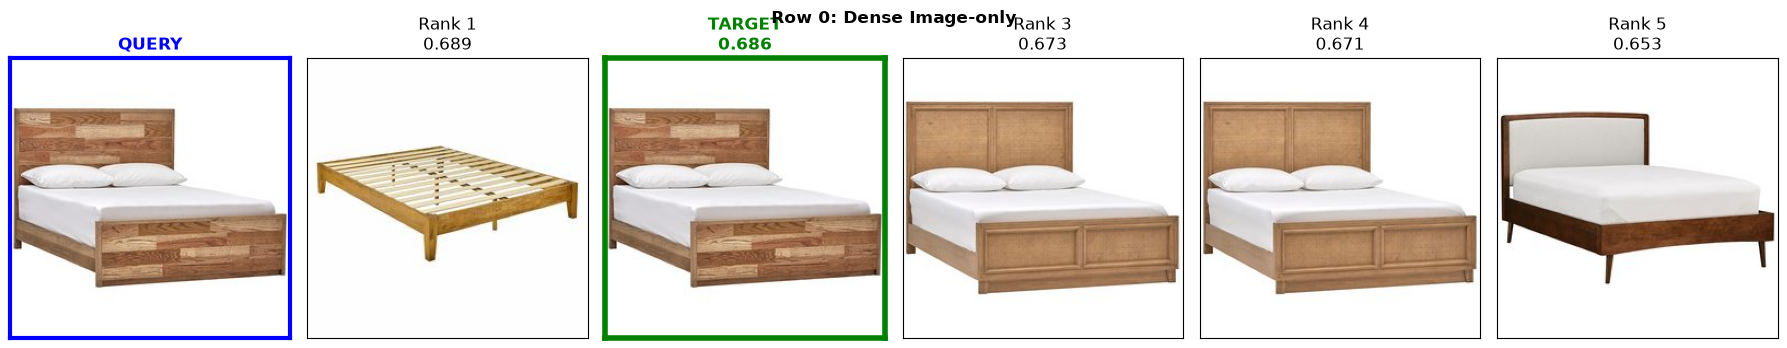

/tmp/ipykernel_5878/3112936054.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


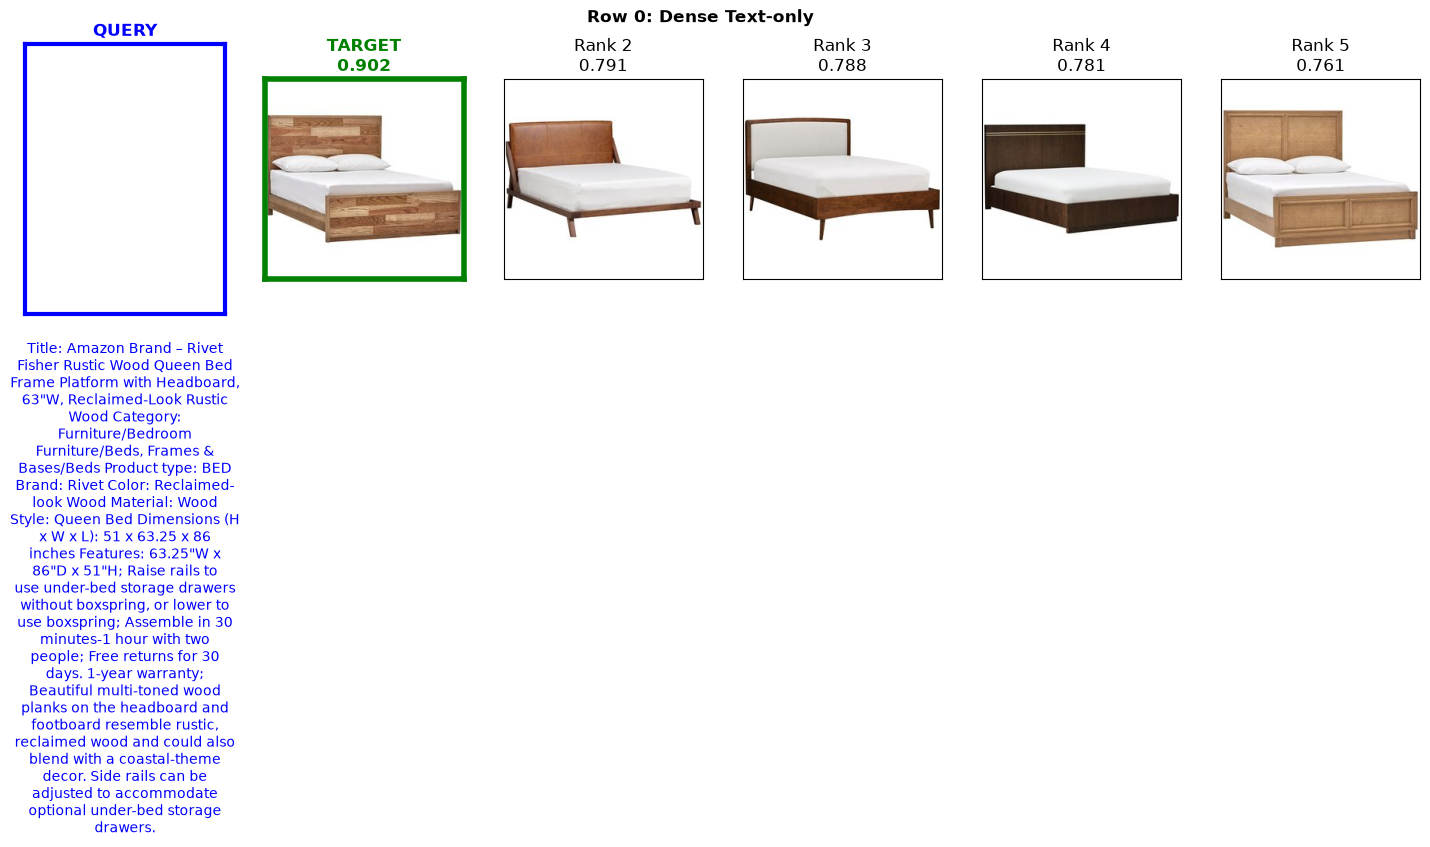

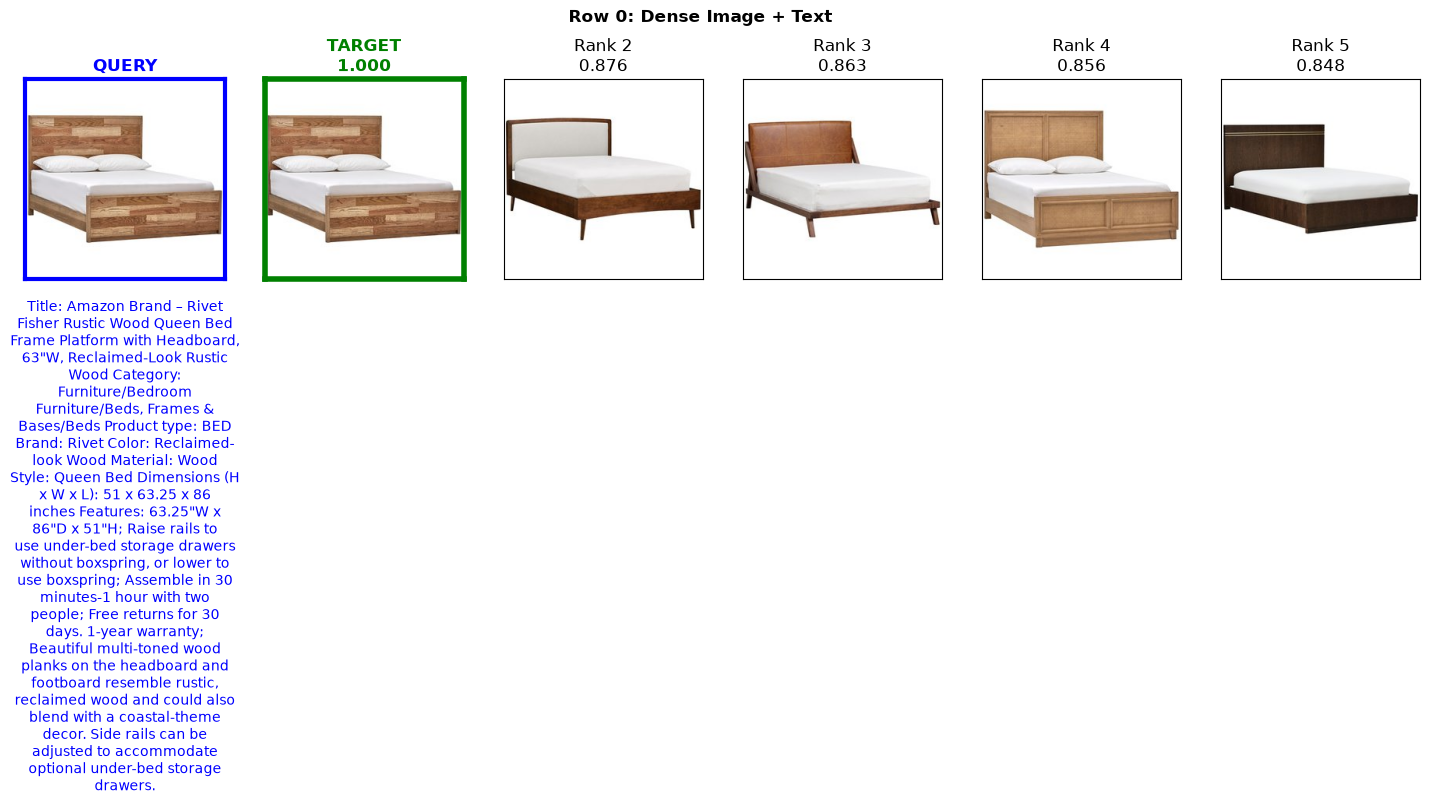

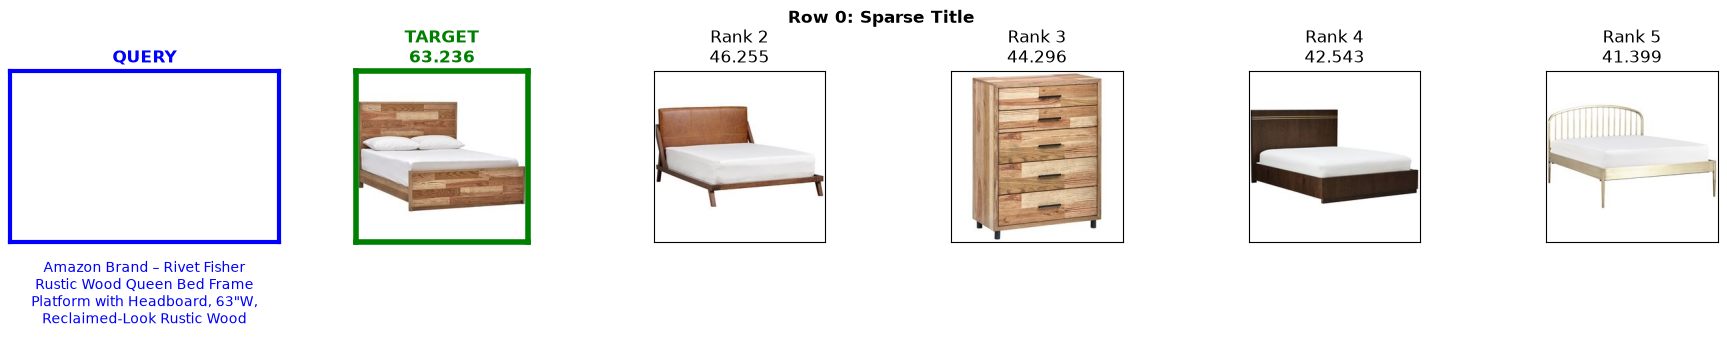

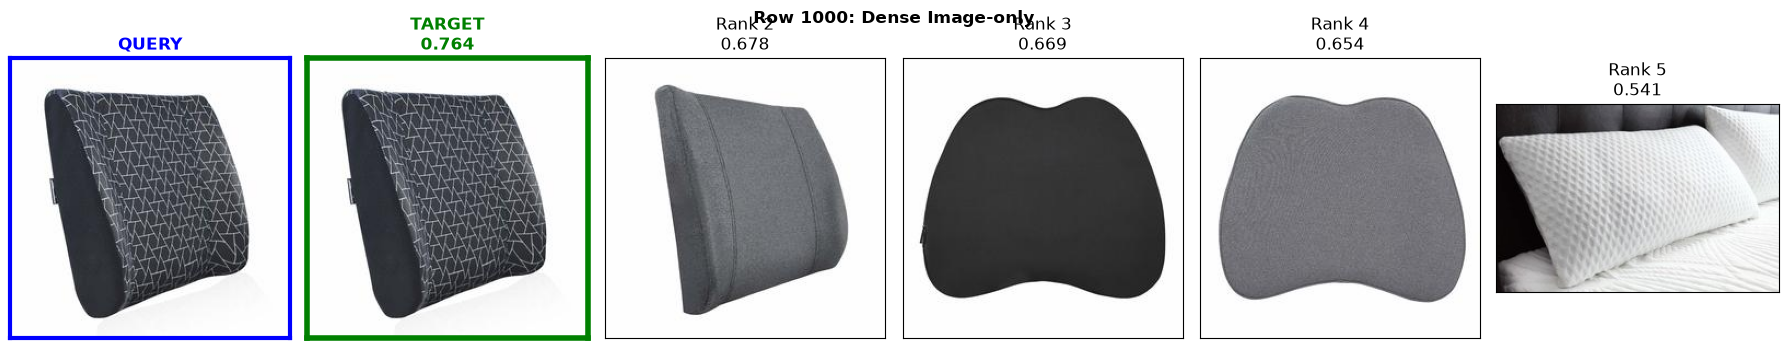

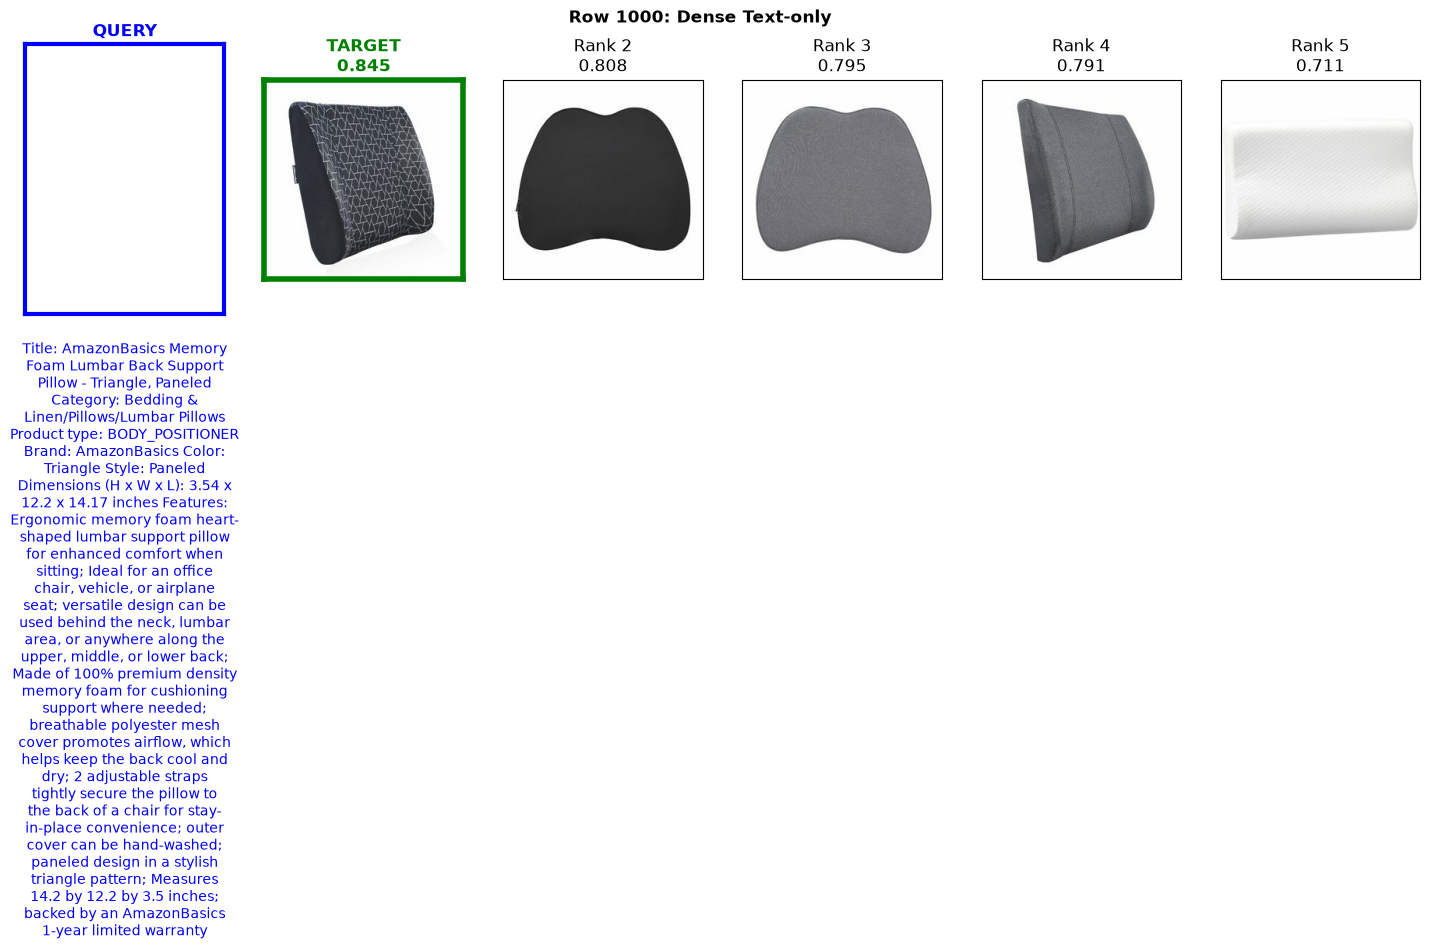

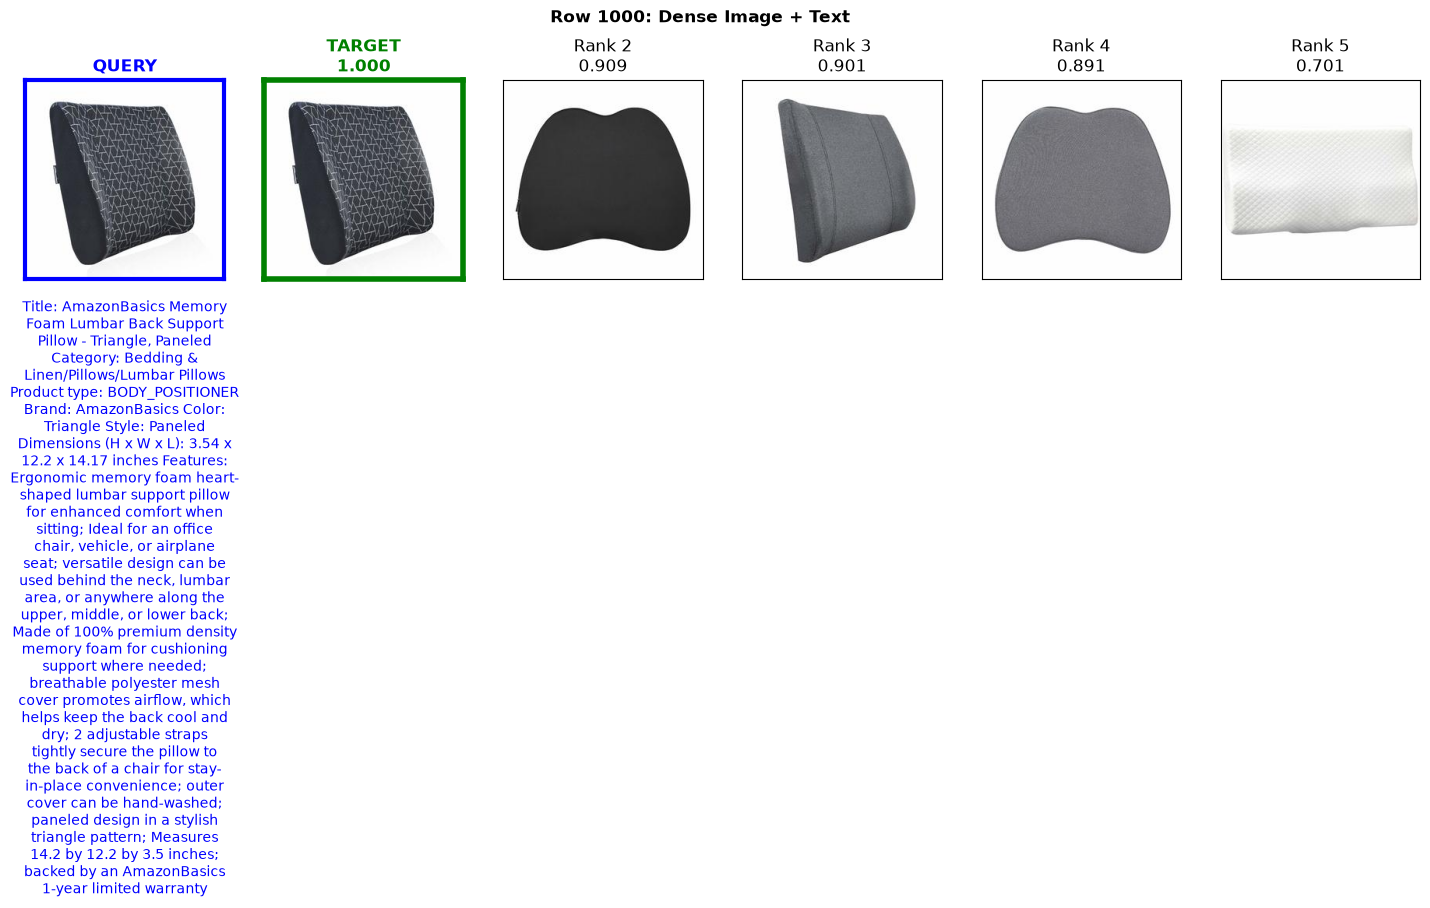

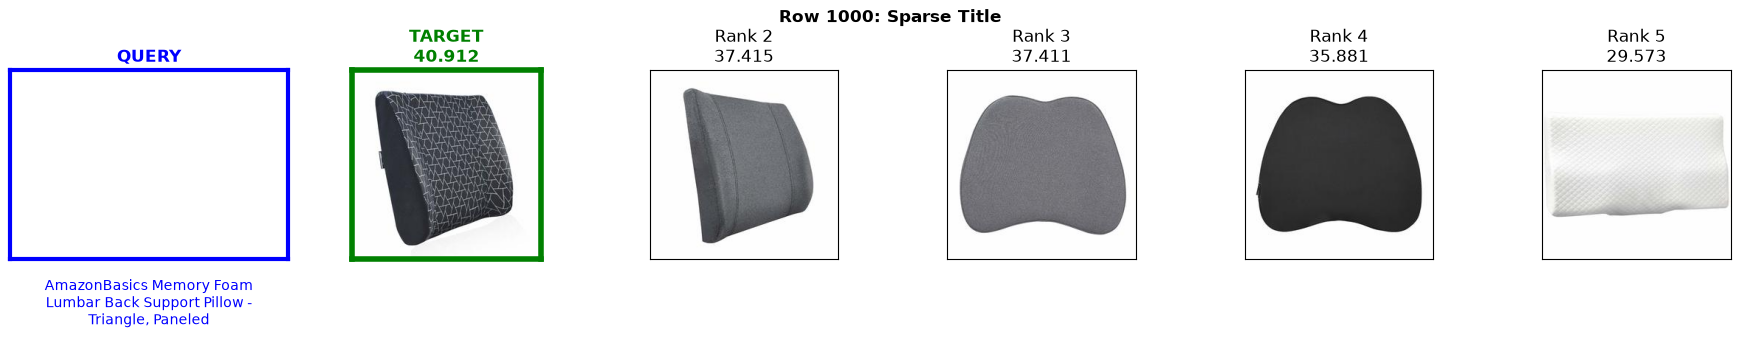

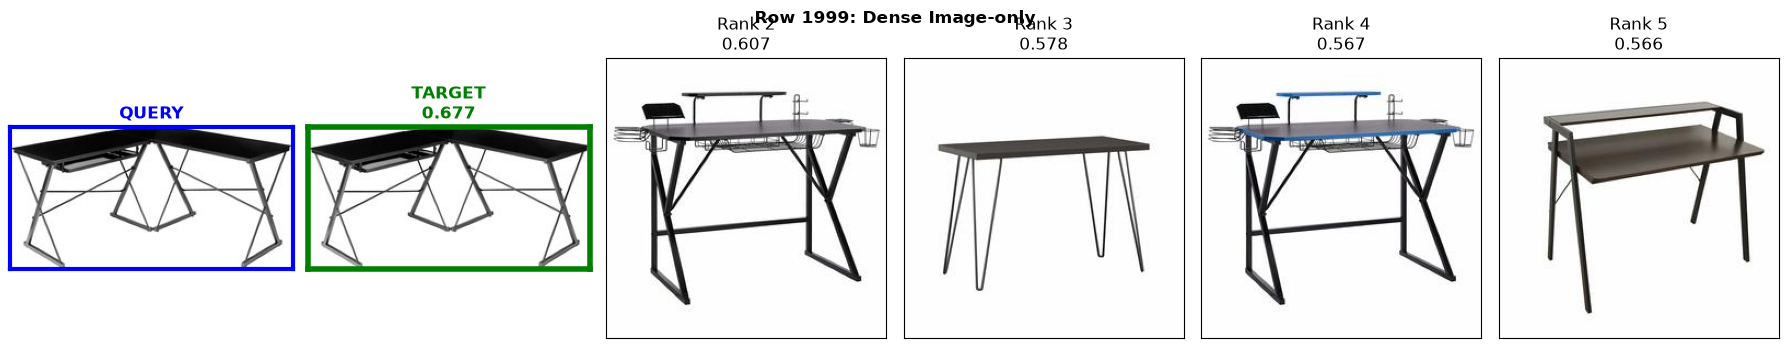

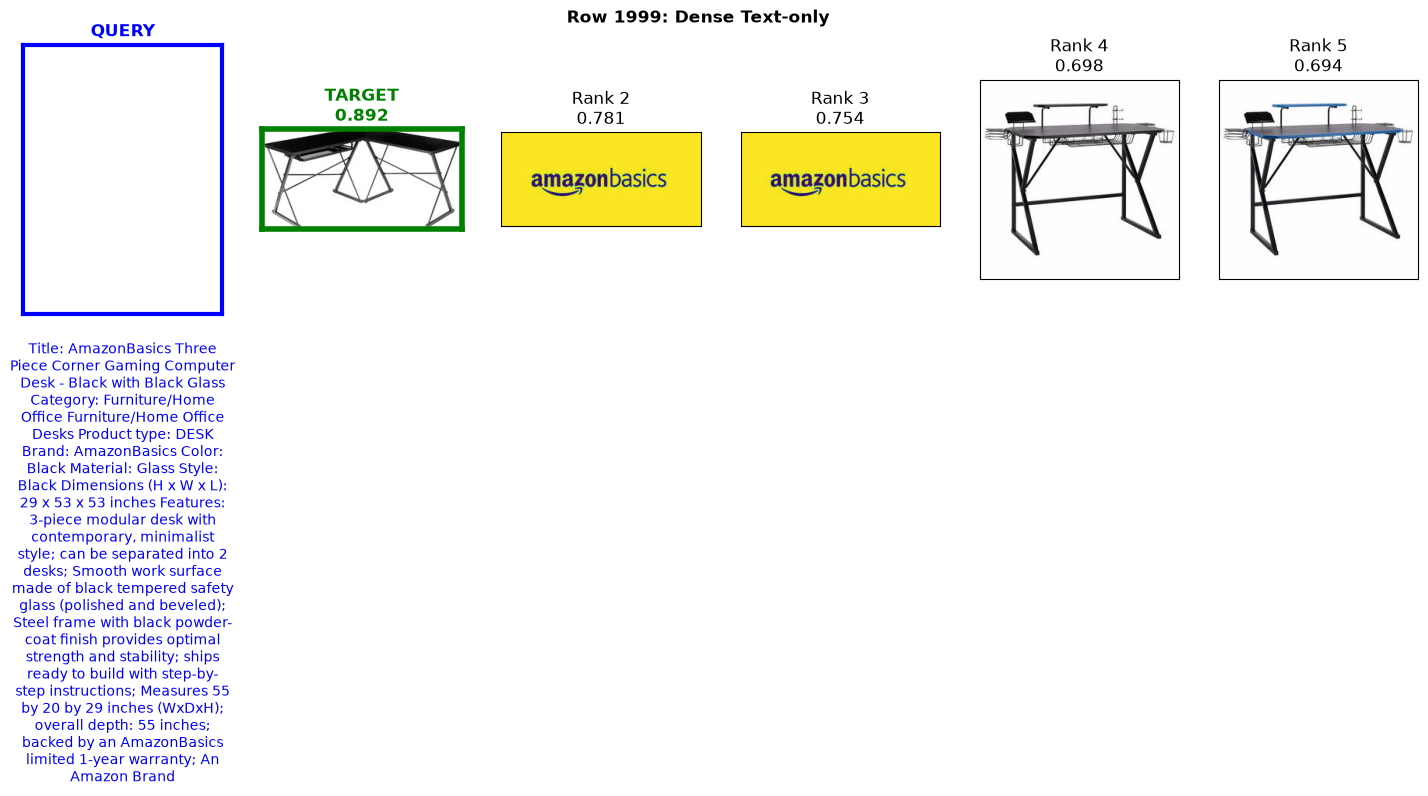

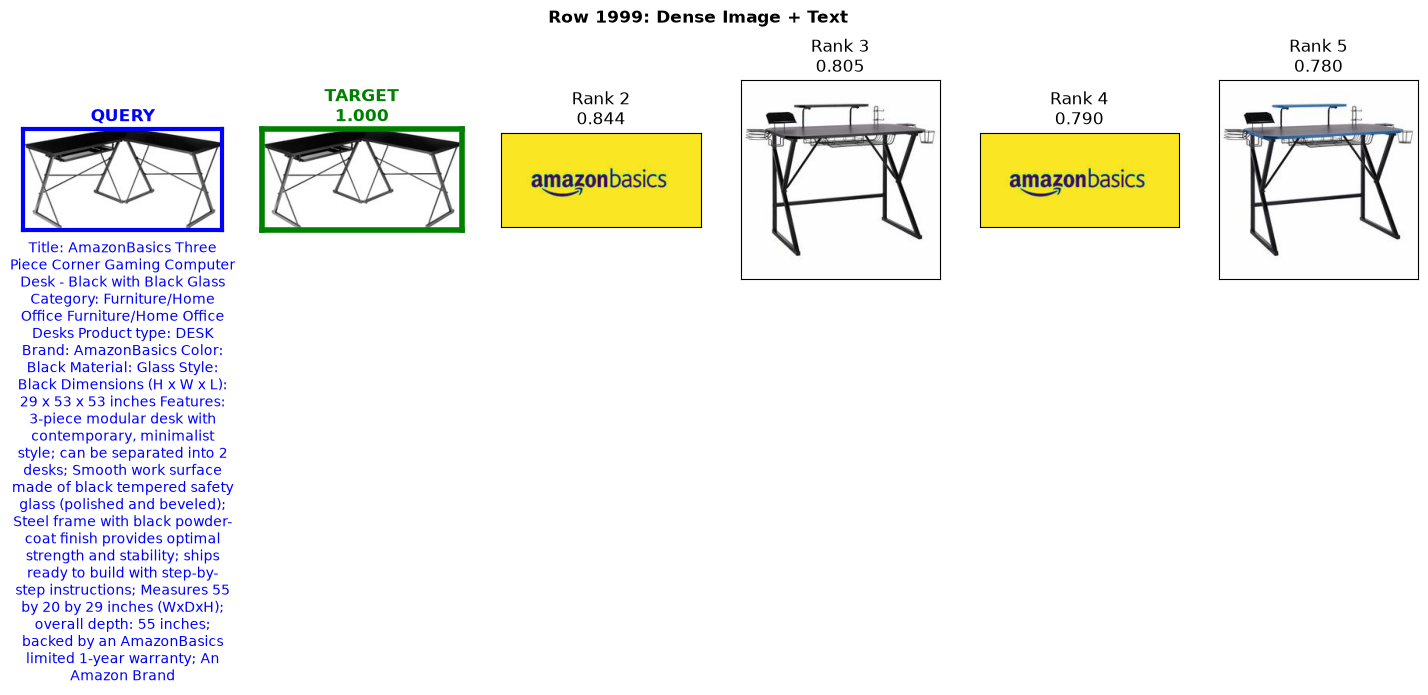

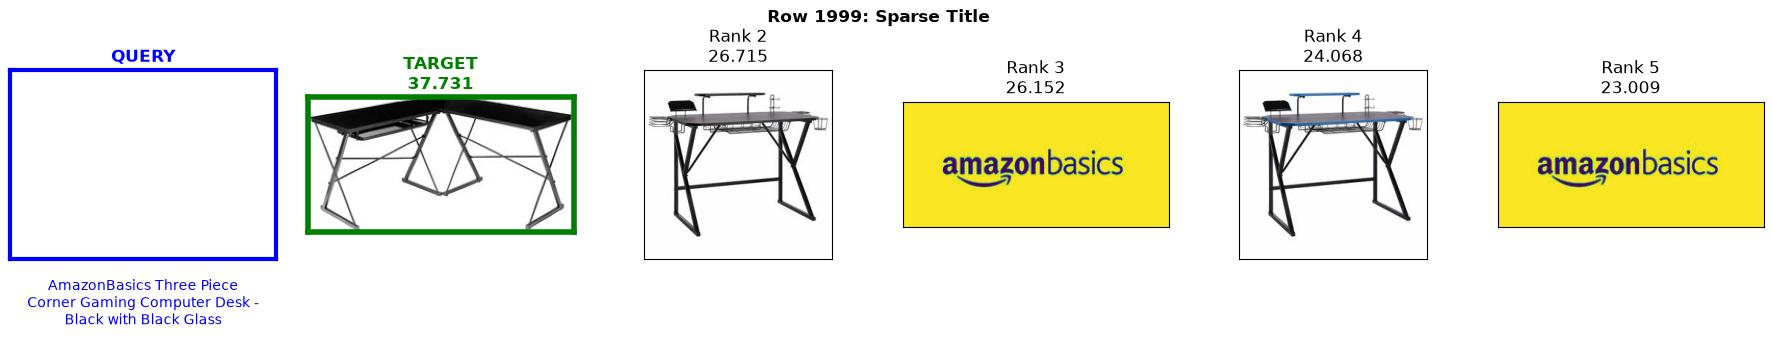

In [ ]:
# TODO: choose representative self-retrieval probes and visualize:
# dense image-only, dense text-only, dense image+text, and sparse title search.
probe_rows = [0, len(catalog) // 2, len(catalog) - 1]

for r in probe_rows:
    img = image_paths[r]
    txt = product_texts[r]
    title = catalog.iloc[r]["title"]

    # 1. Dense Image-only
    res = dense_search(encode_query_dense(img), top_k=5)
    visualize(f"Row {r}: Dense Image-only", res, query_image=img, self_row=r)

    # 2. Dense Text-only
    res = dense_search(encode_query_dense(txt), top_k=5)
    visualize(f"Row {r}: Dense Text-only", res, query_text=txt, self_row=r)

    # 3. Dense Image + Text
    res = dense_search(encode_query_dense({"text": txt, "image": img}), top_k=5)
    visualize(f"Row {r}: Dense Image + Text", res, query_image=img, query_text=txt, self_row=r)

    # 4. Sparse Title-only
    sparse_vectors = splade_encode_batch([title], SPARSE_TOP_N)
    q_indices, q_values = sparse_vectors[0]
    res = sparse_search(q_indices, q_values, top_k=5)
    visualize(f"Row {r}: Sparse Title", res, query_text=title, self_row=r)

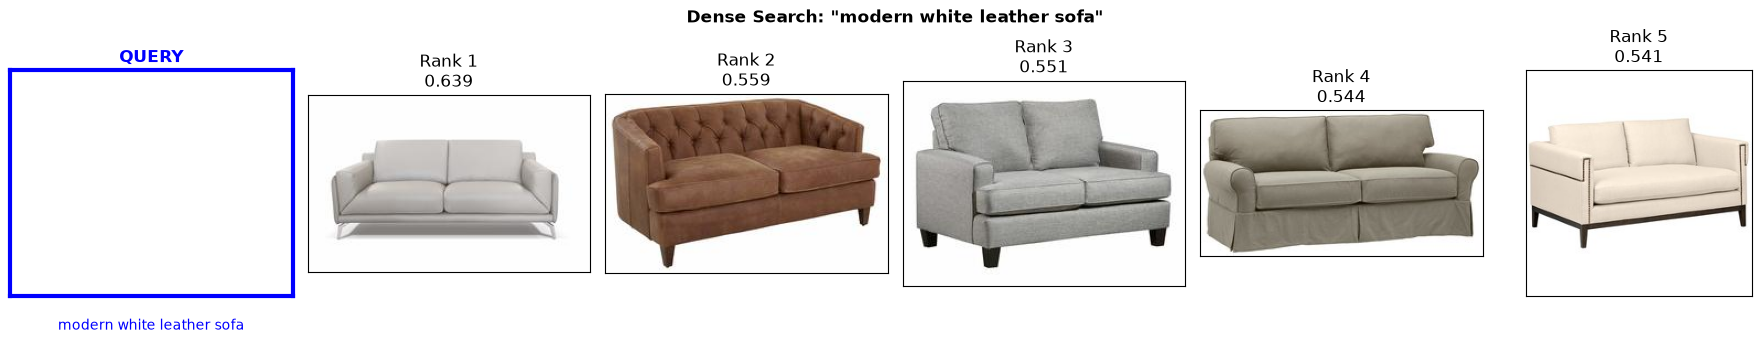

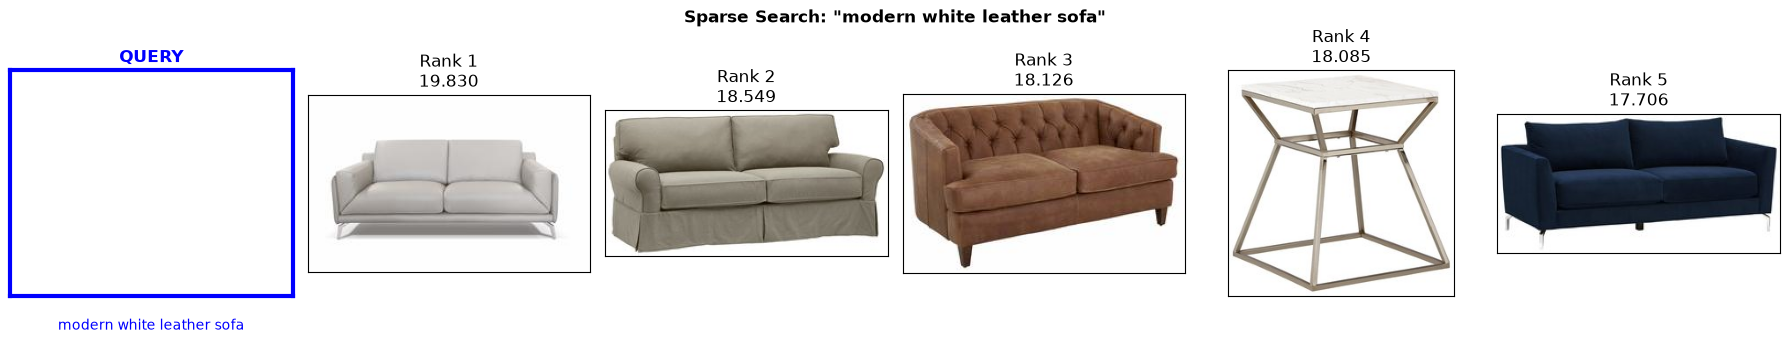

In [ ]:
# TODO: choose at least one free-text product search query and compare dense
# and sparse top-k results visually.
DEMO_QUERY = "modern white leather sofa"

dense_demo = dense_search(encode_query_dense(DEMO_QUERY), top_k=5)
visualize(f'Dense Search: "{DEMO_QUERY}"', dense_demo, query_text=DEMO_QUERY)

demo_sparse_vec = splade_encode_batch([DEMO_QUERY], top_n=SPARSE_TOP_N)[0]
sparse_demo = sparse_search(demo_sparse_vec[0], demo_sparse_vec[1], top_k=5)
visualize(f'Sparse Search: "{DEMO_QUERY}"', sparse_demo, query_text=DEMO_QUERY)


# Stage 2 + 3


# Stage 2 + Stage 3 — Hybrid Retrieval & Cross-Encoder Rerank (inline, self-contained)

This notebook runs Stages 2 and 3 of the pipeline end-to-end on a single
Colab GPU. All code is inlined in cells (not subprocesses) so you see:

* Hugging Face model download progress (widgets)
* per-query retrieval progress (tqdm bars)
* per-query rerank progress (tqdm bars)
* any errors with full Python tracebacks

**Inputs (already produced by Stage 0 + Stage 1):**

* `data/catalog_subset.parquet`
* `data/queries.jsonl`  (20 queries: 10 text, 5 image, 5 image+text)
* `artifacts/embeddings/product_dense.npy`
* `artifacts/embeddings/product_ids.txt`
* `artifacts/index/dense_index.faiss`
* `artifacts/index/sparse_index.npz`
* `artifacts/index/index_manifest.json`

**Outputs (after running this notebook):**

* `outputs/retrieval_results.jsonl`
* `outputs/reranked_results.jsonl`
* `reports/retrieval_summary.md`
* `reports/reranking_summary.md`

**Where to put files on Drive:**

```
MyDrive/AIR_Phase3/
  project/                       <- the whole project folder (Drive upload)
    data/catalog_subset.parquet
    data/queries.jsonl
    artifacts/...
  runs/2026.../                  <- outputs land here
```

**Rerank backend:** this notebook uses the **local** `BAAI/bge-reranker-v2-m3`
cross-encoder on GPU (~2.3 GB download). To switch to the OpenRouter-based
rerank (no model download), see the note in cell 14.



In [ ]:
# Confirm the Drive paths and run folder before starting Stage 2/3.
import os, sys, json, time, subprocess, getpass, zipfile, shutil
from pathlib import Path
from datetime import datetime, timezone

try:
    from google.colab import output, drive
    # drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Colab; using local paths.")

DRIVE_BASE = '.'
DRIVE_PROJECT_DIR = '.'
UPLOAD_ZIP_NAMES = [
    'AIR_Phase3_student_minimal.zip',
    'AIR_Phase3_student_runnable_compact.zip',
    'AIR_Phase3_upload.zip',
]


def _looks_like_project(path):
    return os.path.isfile(os.path.join(path, 'pyproject.toml')) and os.path.isdir(os.path.join(path, 'src'))

if IN_COLAB and not _looks_like_project(DRIVE_PROJECT_DIR):
    os.makedirs(DRIVE_BASE, exist_ok=True)
    upload_zip = next((os.path.join(DRIVE_BASE, name) for name in UPLOAD_ZIP_NAMES
                       if os.path.isfile(os.path.join(DRIVE_BASE, name))), None)
    if upload_zip:
        print(f"Found {upload_zip}, extracting...")
        with zipfile.ZipFile(upload_zip) as zf:
            zf.extractall(DRIVE_BASE)
    else:
        raise SystemExit(
            f"Project folder not found. Upload one of {UPLOAD_ZIP_NAMES} "
            f"to MyDrive/AIR_Phase3/ first.")

if IN_COLAB:
    for candidate in [DRIVE_PROJECT_DIR, f'{DRIVE_BASE}/projectf', DRIVE_BASE]:
        if _looks_like_project(candidate):
            DRIVE_PROJECT_DIR = candidate
            break
    if not _looks_like_project(DRIVE_PROJECT_DIR):
        raise SystemExit("Could not find pyproject.toml and src/ after extracting the upload zip.")
else:
    DRIVE_PROJECT_DIR = os.getcwd()

# Symlink target on local Colab disk for fast I/O.
WORK = '/content/project'
# Where outputs land on Drive.
RUN_TS = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
DRIVE_RUN_DIR = f'{DRIVE_BASE}/runs/{RUN_TS}'

print(f"DRIVE_BASE        = {DRIVE_BASE}")
print(f"DRIVE_PROJECT_DIR = {DRIVE_PROJECT_DIR}")
print(f"WORK              = {WORK}")
print(f"DRIVE_RUN_DIR     = {DRIVE_RUN_DIR}")
gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                      '--format=csv,noheader'],
                     capture_output=True, text=True).stdout.strip()
print(f"GPU: {gpu}")


DRIVE_BASE        = .
DRIVE_PROJECT_DIR = .
WORK              = /content/project
DRIVE_RUN_DIR     = ./runs/20260726T173838Z
GPU: Tesla T4, 15360 MiB


In [ ]:
# Install the retrieval and reranking runtime from pyproject.toml.
import os
import subprocess
import sys

try:
    import tomllib
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tomli"])
    import tomli as tomllib

PROJECT_FILE = os.path.join(DRIVE_PROJECT_DIR, "pyproject.toml") if "DRIVE_PROJECT_DIR" in globals() else "pyproject.toml"
with open(PROJECT_FILE, "rb") as f:
    project_cfg = tomllib.load(f)

deps = list(project_cfg["project"].get("dependencies", []))
deps += list(project_cfg["project"].get("optional-dependencies", {}).get("stage1-gpu", []))
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *deps])
print("dependencies installed from", PROJECT_FILE)
print("If Colab asks for a runtime restart, restart and rerun from the setup cell.")


dependencies installed from ./pyproject.toml
If Colab asks for a runtime restart, restart and rerun from the setup cell.


In [ ]:
# TODO: verify the runtime versions after restarting the notebook kernel.
# --- 2b. Verify versions after the kernel restart above ---
import torch, faiss, sentence_transformers, transformers
print("torch", torch.__version__, "cuda", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')
print("faiss", faiss.__version__)
print("sentence-transformers", sentence_transformers.__version__)
print("transformers", transformers.__version__)
import PIL._typing; print("Pillow", PIL.__version__, "_typing ok")



torch 2.13.0+cu130 cuda True Tesla T4
faiss 1.10.0
sentence-transformers 5.6.1
transformers 5.14.1
Pillow 12.3.0 _typing ok


In [ ]:
# TODO: link the Drive project into local Colab storage for faster I/O.
# --- 3. Symlink project from Drive to local /content ---
import os

if not os.path.isdir(DRIVE_PROJECT_DIR):
    raise SystemExit(
        f"{DRIVE_PROJECT_DIR} not found. Upload the project folder to "
        f"MyDrive/AIR_Phase3/project first.")

if os.path.islink(WORK):
    os.unlink(WORK)
elif os.path.isdir(WORK):
    import shutil; shutil.rmtree(WORK)
os.symlink(DRIVE_PROJECT_DIR, WORK)
os.chdir(WORK)
print("project at:", WORK)
print("top-level:", sorted(os.listdir(WORK))[:15])



project at: /content/project
top-level: ['.config', '.ipynb_checkpoints', 'artifacts', 'data', 'project', 'pyproject.toml', 'reports', 'sample_data', 'src', 'stage1_input']


In [ ]:
# TODO: check that all Stage 0/1 artifacts are present before retrieval.
# --- 4. Verify Stage 0+1 artifacts are present ---
import os
need = [
    'data/catalog_subset.parquet',
    'data/queries.jsonl',
    'artifacts/embeddings/product_dense.npy',
    'artifacts/embeddings/product_ids.txt',
    'artifacts/embeddings/product_sparse.jsonl',
    'artifacts/index/dense_index.faiss',
    'artifacts/index/sparse_index.npz',
    'artifacts/index/index_manifest.json',
]
missing = [p for p in need if not os.path.exists(p)]
if missing:
    raise SystemExit("MISSING ARTIFACTS: " + ', '.join(missing))
print("all", len(need), "artifacts present")

import json
qs = [json.loads(l) for l in open('data/queries.jsonl', encoding='utf-8') if l.strip()]
print(f"queries: {len(qs)} "
      f"(text={sum(1 for q in qs if q['query_type']=='text')}, "
      f"image={sum(1 for q in qs if q['query_type']=='image')}, "
      f"image_text={sum(1 for q in qs if q['query_type']=='image_text')})")



all 8 artifacts present
queries: 20 (text=10, image=5, image_text=5)


In [ ]:
# --- 5. Imports + constants ---
import collections
import json
import os
import time

import numpy as np
import pandas as pd
import scipy.sparse as sp
import faiss
from tqdm.auto import tqdm

# TODO: fill these values before running retrieval and reranking.
DENSE_MODEL  = "Qwen/Qwen3-VL-Embedding-2B"

SPARSE_MODEL = "prithivida/Splade_PP_en_v2"

SPARSE_VOCAB = 30522
SPARSE_TOP_N = 128
DENSE_DIM    = 2048
RRF_K        = 60
W_DENSE      = 0.6
W_SPARSE     = 0.4
TOP_K_DENSE  = 100
TOP_K_SPARSE = 100
PREFUSION    = "rrf"

OUT_DIR = "outputs"
EMB_DIR = "artifacts/embeddings"
INDEX_DIR = "artifacts/index"
DENSE_CACHE  = "artifacts/query_cache/dense_queries.npz"
SPARSE_CACHE = "artifacts/query_cache/sparse_queries.jsonl"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs("artifacts/query_cache", exist_ok=True)
os.makedirs("reports", exist_ok=True)

print("OK")


OK


In [ ]:
# TODO: load the catalog, indexes, ID mapping, and queries used by retrieval.
# --- 6. Load catalog + indexes + queries ---
print("[retrieve] loading catalog data/catalog_subset.parquet")
catalog = pd.read_parquet("data/catalog_subset.parquet")
# Resolve image_path relative to project root
catalog["abs_image_path"] = catalog["image_path"].map(
    lambda p: p if os.path.isabs(p) else os.path.normpath(os.path.join("/content/project", p))
)
print(f"catalog: {len(catalog)} rows")

print("[retrieve] loading FAISS index from artifacts/index")
dense_index = faiss.read_index(os.path.join(INDEX_DIR, "dense_index.faiss"))
print("[retrieve] loading CSR sparse index from artifacts/index")
sparse_index = sp.load_npz(os.path.join(INDEX_DIR, "sparse_index.npz"))
with open(os.path.join(EMB_DIR, "product_ids.txt"), encoding="utf-8") as f:
    product_ids = [l.strip() for l in f if l.strip()]
print(f"dense: {dense_index.ntotal} vectors, d={dense_index.d}; "
      f"sparse: {sparse_index.shape}, nnz={sparse_index.nnz}; ids: {len(product_ids)}")

print("[retrieve] loading queries data/queries.jsonl")
queries = []
with open("data/queries.jsonl", encoding="utf-8") as f:
    for ln, line in enumerate(f, 1):
        line = line.strip()
        if not line: continue
        q = json.loads(line)
        for k in ("query_id", "query_text", "query_image_path", "query_type", "split"):
            if k not in q:
                raise ValueError(f"line {ln} missing '{k}'")
        if q["query_type"] not in ("text", "image", "image_text"):
            raise ValueError(f"line {ln}: bad query_type {q['query_type']!r}")
        if q["query_type"] in ("text", "image_text") and not q["query_text"]:
            raise ValueError(f"line {ln}: text/image_text query needs query_text")
        if q["query_type"] in ("image", "image_text") and not q["query_image_path"]:
            raise ValueError(f"line {ln}: image/image_text query needs query_image_path")
        if q["query_image_path"]:
            rel = q["query_image_path"]
            abs_p = rel if os.path.isabs(rel) else os.path.join("/content/project", rel)
            abs_p = os.path.normpath(abs_p)
            q["abs_image_path"] = abs_p
        queries.append(q)
print(f"queries: {len(queries)}; by type "
      f"{dict(collections.Counter(q['query_type'] for q in queries))}")



[retrieve] loading catalog data/catalog_subset.parquet
catalog: 2000 rows
[retrieve] loading FAISS index from artifacts/index
[retrieve] loading CSR sparse index from artifacts/index
dense: 2000 vectors, d=2048; sparse: (2000, 30522), nnz=240869; ids: 2000
[retrieve] loading queries data/queries.jsonl
queries: 20; by type {'text': 10, 'image': 5, 'image_text': 5}


In [ ]:
# --- 7. Load Qwen3-VL-Embedding-2B on GPU ---
# This cell downloads the model the first time it runs.
import torch
from sentence_transformers import SentenceTransformer

print(f"loading dense model {DENSE_MODEL} on cuda")

# TODO: instantiate the dense query encoder on cuda using the same model and
# dtype policy used for product embeddings.
dtype = torch.float16 if DEVICE == 'cuda' else torch.float32
dense_query_model = SentenceTransformer(DENSE_MODEL, model_kwargs={'torch_dtype': dtype})
dense_query_model.to(DEVICE)

print("loaded:", DENSE_MODEL)


loading dense model Qwen/Qwen3-VL-Embedding-2B on cuda


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

loaded: Qwen/Qwen3-VL-Embedding-2B


In [ ]:
# --- 8. Load SPLADE++ sparse encoder on GPU ---
# Downloads prithivida/Splade_PP_en_v2 (~440 MB) the first time.
from transformers import AutoTokenizer, AutoModelForMaskedLM

print(f"loading sparse model {SPARSE_MODEL} on cuda")
sp_tokenizer = AutoTokenizer.from_pretrained(SPARSE_MODEL)
sp_model = AutoModelForMaskedLM.from_pretrained(SPARSE_MODEL).to("cuda").eval()
print("loaded:", SPARSE_MODEL, "| vocab:", sp_model.config.vocab_size)

@torch.no_grad()
def splade_encode_batch(texts, top_n=SPARSE_TOP_N, max_len=256):
    enc = sp_tokenizer(texts, padding=True, truncation=True,
                       max_length=max_len, return_tensors="pt").to("cuda")

    # TODO: run the masked-LM, compute SPLADE weights, mask padding tokens,
    # keep each row's top-N terms, and return (indices, values) arrays.
    outputs = sp_model(**enc)
    weights = torch.log(1 + torch.relu(outputs.logits))
    weights = weights * enc['attention_mask'].unsqueeze(-1)
    term_weights = torch.max(weights, dim=1)[0]
    results = []
    for i in range(term_weights.shape[0]):
        row_weights = term_weights[i]
        k = min(top_n, (row_weights > 0).sum().item())
        if k == 0:
            results.append((np.array([], dtype=np.int64), np.array([], dtype=np.float32)))
        else:
            topk = torch.topk(row_weights, k)
            results.append((topk.indices.cpu().numpy(), topk.values.cpu().numpy()))
    return results

print("splade_encode_batch ready")


loading sparse model prithivida/Splade_PP_en_v2 on cuda


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

loaded: prithivida/Splade_PP_en_v2 | vocab: 30522
splade_encode_batch ready


In [ ]:
# TODO: decide how this run should handle image queries with missing files.
# --- 8b. Patch missing image paths: skip image-bearing queries whose file is missing ---
import os

queries_orig = list(queries)
queries = []
skipped = []
for q in queries_orig:
    if q.get('query_image_path'):
        rel = q['query_image_path']
        abs_p = rel if os.path.isabs(rel) else os.path.join('/content/project', rel)
        abs_p = os.path.normpath(abs_p)
        if not os.path.exists(abs_p):
            print(f"  SKIP {q['query_id']} ({q['query_type']}): missing {abs_p}")
            skipped.append(q['query_id'])
            continue
    queries.append(q)
print()
print(f"Will process {len(queries)}/{len(queries_orig)} queries (skipped: {skipped})")
print("(the skipped queries are dropped from this run, not replaced)")


Will process 20/20 queries (skipped: [])
(the skipped queries are dropped from this run, not replaced)


In [ ]:
# --- 9. Encode dense query vectors (cached) ---
from PIL import Image

cached = {}
if os.path.isfile(DENSE_CACHE):
    with np.load(DENSE_CACHE, allow_pickle=False) as z:
        for k in z.files:
            cached[k] = z[k]
    print(f"dense query cache hit: {len(cached)} vectors")

def _load_image(path):
    """Load image as PIL.Image so Qwen3-VL doesn't try to base64 the path."""
    return Image.open(path).convert("RGB")

def _dense_input_for_query(q):
    if q["query_type"] == "text":
        return q["query_text"]
    if q["query_type"] == "image":
        return _load_image(q["abs_image_path"])
    return {"text": q["query_text"], "image": _load_image(q["abs_image_path"])}

def _dense_encode_one(q):
    fn = getattr(dense_model, "encode_query", None)
    inp = _dense_input_for_query(q)
    kw = dict(convert_to_numpy=True, normalize_embeddings=True)

    # TODO: encode one prepared query input. Prefer encode_query when it is
    # available; otherwise use dense_model.encode. Return a flat float32 vector.
    if fn is not None:
        res = fn([inp], **kw)
    else:
        res = dense_model.encode([inp], **kw)

    return res[0].astype(np.float32) if len(res.shape) > 1 else res.astype(np.float32)

todo = [q for q in queries if q["query_id"] not in cached]
print(f"encoding {len(todo)} dense query vectors ({len(cached)} cached)")
out = {}
for q in tqdm(todo, desc="dense query encode"):
    out[q["query_id"]] = _dense_encode_one(q)
all_dense = {**cached, **out}
if out:
    os.makedirs(os.path.dirname(DENSE_CACHE), exist_ok=True)
    np.savez(DENSE_CACHE, **all_dense)
    print(f"saved {len(all_dense)} dense query vectors to {DENSE_CACHE}")
print("dense query vectors:", len(all_dense))


encoding 20 dense query vectors (0 cached)


dense query encode:   0%|          | 0/20 [00:00<?, ?it/s]

saved 20 dense query vectors to artifacts/query_cache/dense_queries.npz
dense query vectors: 20


In [ ]:
# --- 10. Encode sparse query vectors (cached) ---
cached = {}
if os.path.isfile(SPARSE_CACHE):
    with open(SPARSE_CACHE, encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            if rec.get("indices"):
                cached[rec["query_id"]] = (
                    np.asarray(rec["indices"], dtype=np.int32),
                    np.asarray(rec["values"], dtype=np.float32),
                )
    print(f"sparse query cache hit: {len(cached)} vectors")

todo = [q for q in queries
        if q["query_type"] in ("text", "image_text")
        and q["query_id"] not in cached]
print(f"encoding {len(todo)} sparse query vectors")
BATCH = 16
new_records = []
for s in tqdm(range(0, len(todo), BATCH), desc="sparse query encode"):
    batch = [q["query_text"] for q in todo[s:s+BATCH]]

    # TODO: encode this batch with splade_encode_batch, update cached, and add
    # JSON-serializable rows to new_records.
    encoded = splade_encode_batch(batch, SPARSE_TOP_N)
    for j, (idx, val) in enumerate(encoded):
        q_id = todo[s + j]["query_id"]
        cached[q_id] = (idx, val)
        new_records.append({
            'query_id': q_id,
            'indices': idx.tolist(),
            'values': val.tolist()
        })

if new_records:
    with open(SPARSE_CACHE, "a", encoding="utf-8") as f:
        for rec in new_records:
            f.write(json.dumps(rec) + "\n")
    print(f"appended {len(new_records)} sparse query vectors to {SPARSE_CACHE}")
print("sparse query vectors:", len(cached))


encoding 15 sparse query vectors


sparse query encode:   0%|          | 0/1 [00:00<?, ?it/s]

appended 15 sparse query vectors to artifacts/query_cache/sparse_queries.jsonl
sparse query vectors: 15


In [ ]:
# --- 11. Hybrid search + RRF/weighted prefusion + write outputs ---
def normalize_scores(pairs):
    if not pairs: return {}
    vals = np.array([s for _, s in pairs], dtype=np.float32)
    lo, hi = float(vals.min()), float(vals.max())
    if hi - lo < 1e-9:
        return {i: 0.0 for i, _ in pairs}
    return {i: float((s - lo) / (hi - lo)) for i, s in pairs}

def dense_search(di, q_vec, top_k):
    q = q_vec.reshape(1, -1).astype(np.float32)
    scores, idx = di.search(q, top_k)
    return [(int(i), float(s)) for i, s in zip(idx[0], scores[0]) if i != -1]

def sparse_search(si, q_idx, q_val, top_k):
    if q_idx is None or len(q_idx) == 0: return []
    v = np.zeros(si.shape[1], dtype=np.float32)
    v[np.asarray(q_idx, dtype=np.int64)] = np.asarray(q_val, dtype=np.float32)
    scores = np.asarray(si.dot(v)).ravel()
    if top_k >= len(scores):
        top = np.argsort(-scores)
    else:
        top = np.argpartition(-scores, top_k)[:top_k]
        top = top[np.argsort(-scores[top])]
    return [(int(i), float(scores[i])) for i in top]

def merge_and_score(d_hits, s_hits, query_type, prefusion_method):
    sparse_applicable = query_type in ("text", "image_text")
    d_norm = normalize_scores(d_hits)
    s_norm = normalize_scores(s_hits) if sparse_applicable else {}
    d_rank = {i: r for r, (i, _) in enumerate(d_hits)}
    s_rank = {i: r for r, (i, _) in enumerate(s_hits)}
    d_score_map = {i: s for i, s in d_hits}
    s_score_map = {i: s for i, s in s_hits}
    candidates = set(d_score_map) | set(s_score_map)

    # TODO: build one row per candidate with its dense score, sparse score,
    # prefusion score, and source list. Support both RRF and weighted fusion,
    # then sort rows by prefusion score descending.
    merged = []
    for i in candidates:
        d_s = d_score_map.get(i, 0.0)
        s_s = s_score_map.get(i, 0.0) if sparse_applicable else 0.0

        # Determine source origins
        src = []
        if i in d_score_map: src.append("dense")
        if i in s_score_map and sparse_applicable: src.append("sparse")

        # Calculate the prefusion score based on the chosen strategy
        if prefusion_method == "rrf":
            rrf_d = 1.0 / (RRF_K + d_rank[i]) if i in d_rank else 0.0
            rrf_s = 1.0 / (RRF_K + s_rank[i]) if i in s_rank and sparse_applicable else 0.0
            pf_s = rrf_d + rrf_s
        elif prefusion_method == "weighted":
            pf_s = d_norm.get(i, 0.0) * W_DENSE + (s_norm.get(i, 0.0) * W_SPARSE if sparse_applicable else 0.0)
        else:
            pf_s = d_s

        merged.append((i, d_s, s_s, pf_s, src))

    merged.sort(key=lambda x: x[3], reverse=True)
    return merged

out_records = []
n_unique_cands, dense_n, sparse_n, overlap = [], 0, 0, 0
t0 = time.time()
for q in tqdm(queries, desc="retrieval"):
    if q["query_id"] in all_dense:
        d_hits = dense_search(dense_index, all_dense[q["query_id"]], TOP_K_DENSE)
    else:
        d_hits = []
    s_hits = []
    if q["query_type"] in ("text", "image_text") and q["query_id"] in cached:
        qidx, qval = cached[q["query_id"]]
        s_hits = sparse_search(sparse_index, qidx, qval, TOP_K_SPARSE)
    merged = merge_and_score(d_hits, s_hits, q["query_type"], PREFUSION)
    sparse_applicable = q["query_type"] in ("text", "image_text")
    results = []
    d_set = {i for i, _ in d_hits}
    s_set = {i for i, _ in s_hits}
    for rank, (i, d_s, s_s, pf_s, src) in enumerate(merged, 1):
        results.append({
            "rank": rank,
            "product_id": product_ids[i],
            "dense_score": d_s,
            "sparse_score": s_s if sparse_applicable else None,
            "prefusion_score": pf_s,
            "source": src,
        })
    out_records.append({
        "query_id": q["query_id"],
        "query_type": q["query_type"],
        "run_name": "hybrid_dense_sparse_prefusion",
        "sparse_applicable": sparse_applicable,
        "results": results,
    })
    dense_n += len(d_hits); sparse_n += len(s_hits)
    overlap += len(d_set & s_set)
    n_unique_cands.append(len(merged))

print(f"\nretrieval done in {time.time()-t0:.1f}s | "
      f"mean unique cands/query={np.mean(n_unique_cands):.1f} | "
      f"mean dense-hits={dense_n/len(queries):.1f} | "
      f"mean sparse-hits={sparse_n/len(queries):.1f} | "
      f"mean overlap={overlap/len(queries):.1f}")

with open(f"{OUT_DIR}/retrieval_results.jsonl", "w", encoding="utf-8") as f:
    for r in out_records:
        f.write(json.dumps(r) + "\n")
print(f"wrote {len(out_records)} lines to outputs/retrieval_results.jsonl")

by_type = collections.Counter(q["query_type"] for q in queries)
n_text, n_image, n_image_text = by_type.get("text", 0), by_type.get("image", 0), by_type.get("image_text", 0)
examples = []
for r in out_records[:3]:
    top3 = r["results"][:3]
    examples.append(f"- **{r['query_id']}** ({r['query_type']}) -> " + ", ".join(
        f"#{x['rank']} {x['product_id']} (pf={x['prefusion_score']:.3f})" for x in top3))
md = [
    "# Stage 2 - Retrieval Summary", "",
    f"- Queries by type: text={n_text}, image={n_image}, image_text={n_image_text} (total={len(queries)})",
    f"- Dense top-K: {TOP_K_DENSE} | Sparse top-K: {TOP_K_SPARSE}",
    f"- Prefusion method: **{PREFUSION}** (RRF k={RRF_K} | weighted w_dense={W_DENSE}, w_sparse={W_SPARSE})",
    f"- Average unique candidates per query: **{np.mean(n_unique_cands):.1f}**",
    f"- Average candidates in BOTH dense and sparse: **{overlap/len(queries):.1f}**", "",
    "## Top results for the first 3 queries", "", *examples, "",
]
with open("reports/retrieval_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(md))
print("wrote reports/retrieval_summary.md")


retrieval:   0%|          | 0/20 [00:00<?, ?it/s]


retrieval done in 0.1s | mean unique cands/query=148.3 | mean dense-hits=100.0 | mean sparse-hits=75.0 | mean overlap=26.6
wrote 20 lines to outputs/retrieval_results.jsonl
wrote reports/retrieval_summary.md


In [ ]:
# TODO: run and review the Stage 2 schema checks after writing retrieval output.
# --- 12. Stage 2 schema sanity tests (inline) ---
import json, os
n_pass = n_fail = 0
def check(name, cond):
    global n_pass, n_fail
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}")
    if cond: n_pass += 1
    else: n_fail += 1

records = [json.loads(l) for l in open("outputs/retrieval_results.jsonl", encoding="utf-8") if l.strip()]
check("retrieval_results.jsonl non-empty", bool(records))
catalog = pd.read_parquet("data/catalog_subset.parquet")
catalog_ids = set(catalog["product_id"].tolist())
queries_by_id = {q["query_id"]: q for q in queries}
for r in records:
    check(f"{r['query_id']} in queries", r["query_id"] in queries_by_id)
    check(f"{r['query_id']} run_name is hybrid", r.get("run_name") == "hybrid_dense_sparse_prefusion")
    check(f"{r['query_id']} sparse_applicable matches",
          r.get("sparse_applicable") == (queries_by_id[r["query_id"]]["query_type"] != "image"))
    for h in r.get("results", []):
        check(f"{r['query_id']} hit {h['product_id']} in catalog", h["product_id"] in catalog_ids)
        check(f"{r['query_id']} hit has prefusion_score", "prefusion_score" in h)
        check(f"{r['query_id']} hit has source", "source" in h)
        check(f"{r['query_id']} hit rank is int", isinstance(h.get("rank"), int))
print(f"\n{n_pass} passed, {n_fail} failed")



Streaming output truncated to the last 5000 lines.
  [PASS] q013 hit rank is int
  [PASS] q013 hit B082JJJKT3|amazon.com in catalog
  [PASS] q013 hit has prefusion_score
  [PASS] q013 hit has source
  [PASS] q013 hit rank is int
  [PASS] q013 hit B075X4YDCR|amazon.com in catalog
  [PASS] q013 hit has prefusion_score
  [PASS] q013 hit has source
  [PASS] q013 hit rank is int
  [PASS] q013 hit B078J4X3WP|amazon.in in catalog
  [PASS] q013 hit has prefusion_score
  [PASS] q013 hit has source
  [PASS] q013 hit rank is int
  [PASS] q013 hit B07Y3Q62Y7|amazon.in in catalog
  [PASS] q013 hit has prefusion_score
  [PASS] q013 hit has source
  [PASS] q013 hit rank is int
  [PASS] q013 hit B01DN8TG46|amazon.co.uk in catalog
  [PASS] q013 hit has prefusion_score
  [PASS] q013 hit has source
  [PASS] q013 hit rank is int
  [PASS] q013 hit B07CSX7N4X|amazon.com in catalog
  [PASS] q013 hit has prefusion_score
  [PASS] q013 hit has source
  [PASS] q013 hit rank is int
  [PASS] q013 hit B0853L359H|am

In [ ]:
# --- 13. Load BGE cross-encoder reranker ---
# This model scores each (query_text, product_text) pair.
from sentence_transformers import CrossEncoder

CE_MODEL_NAME = "BAAI/bge-reranker-v2-m3"
print(f"loading cross-encoder {CE_MODEL_NAME} on cuda")

# TODO: load the cross-encoder with the model name above, cuda device, and a
# max length suitable for the product text built in the next cell.
from sentence_transformers import CrossEncoder
ce_model = CrossEncoder('BAAI/bge-reranker-v2-m3', max_length=512, default_activation_function=torch.nn.Identity())
ce_model.model.to(DEVICE)

print("loaded:", CE_MODEL_NAME)


loading cross-encoder BAAI/bge-reranker-v2-m3 on cuda


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

loaded: BAAI/bge-reranker-v2-m3


In [ ]:
# --- 14. Build the (query_text, product_text) rerank input pairs ---
# Uses product metadata fields: title, product_type, category, brand, color,
# material, style, bullet points, description.
import math

cat_by_id = {r.product_id: r for r in catalog.itertuples()}

def _safe(v, default=''):
    """Return v as string; treat None and NaN as empty."""
    if v is None: return default
    if isinstance(v, float) and math.isnan(v): return default
    return v

def build_product_text(row, max_chars=1024):
    fields = {
        "Title": _safe(getattr(row, 'title', None)),
        "Category": _safe(getattr(row, 'category_path', None)),
        "Product type": _safe(getattr(row, 'product_type', None)),
        "Brand": _safe(getattr(row, 'brand', None)),
        "Color": _safe(getattr(row, 'color', None)),
        "Material": _safe(getattr(row, 'material', None)),
        "Style": _safe(getattr(row, 'style', None)),
        "Features": _safe(getattr(row, 'bullet_points', None)),
        "Description": _safe(getattr(row, 'description', None)),
    }

    # TODO: choose how much product text to keep, format non-empty fields for
    # the cross-encoder, and return a string no longer than max_chars.
    parts = []
    for key, value in fields.items():
        if value:
            parts.append(f"{key}: {value}")
    text = " | ".join(parts)
    return text[:max_chars]

def query_text_for(q):
    if q["query_type"] == "image":
        # TODO: decide the text surrogate used for image-only queries.
        return 'find similar item'
    return q["query_text"]

# TODO: choose the reranking depth.
RERANK_TOP_N = 100
print(f"building rerank input pairs (top {RERANK_TOP_N} per query)")
pairs_per_query = []
for r in tqdm(out_records, desc="build pairs"):
    q = queries_by_id[r["query_id"]]
    qtext = query_text_for(q)
    hits = r["results"][:RERANK_TOP_N]
    pairs = []
    for h in hits:
        row = cat_by_id.get(h["product_id"])
        if row is None: continue
        pairs.append((qtext, build_product_text(row)))
    pairs_per_query.append((r["query_id"], q["query_type"], pairs))
total = sum(len(p[2]) for p in pairs_per_query)
print(f"total (query, product) pairs to score: {total}")


building rerank input pairs (top 100 per query)


build pairs:   0%|          | 0/20 [00:00<?, ?it/s]

total (query, product) pairs to score: 2000


In [ ]:
# --- 15. Score all pairs with BGE + write reranked_results.jsonl + summary ---
import math

def zscore(vals):
    if len(vals) == 0: return []
    arr = np.array(vals, dtype=np.float32)
    mu, sd = float(arr.mean()), float(arr.std() + 1e-9)
    return [float((v - mu) / sd) for v in arr]

# TODO: choose fusion weights for each query type.
WEIGHTS = {
    "text": {"ce": 0.4, "dense": 0.3, "sparse": 0.3},
    "image": {"ce": 0.0, "dense": 1.0, "sparse": 0.0},
    "image_text": {"ce": 0.3, "dense": 0.4, "sparse": 0.3},
}

rerank_records = []
strategy_a_lines = []
t0 = time.time()
for qid, qtype, pairs in tqdm(pairs_per_query, desc="rerank"):
    q = queries_by_id[qid]
    retrieval = next(r for r in out_records if r["query_id"] == qid)
    hits = retrieval["results"][:RERANK_TOP_N]
    weights = WEIGHTS[qtype]

    # TODO: score pairs with ce_model.predict, z-score the cross-encoder,
    # dense, and sparse scores per query, fuse them with weights, sort by the
    # final score, and append both rerank_records and strategy_a_lines.
    ce_raw = ce_model.predict(pairs, batch_size=32) if pairs else []
    d_raw = [h.get("dense_score", 0.0) for h in hits]
    s_raw = [h.get("sparse_score", 0.0) if h.get("sparse_score") is not None else 0.0 for h in hits]

    d_z = zscore(d_raw)
    s_z = zscore(s_raw)
    c_z = zscore(ce_raw)

    scored_hits = []
    for i, h in enumerate(hits):
        # 4. Apply the configured fusion weights
        final_score = (d_z[i] * weights["dense"] +
                        s_z[i] * weights["sparse"] +
                        c_z[i] * weights["ce"])

        scored_hits.append({
            "product_id": h["product_id"],
            "final_score": final_score,
            "cross_encoder_score": float(ce_raw[i]) if len(ce_raw) > 0 else 0.0,
            "dense_score": h.get("dense_score"),
            "sparse_score": h.get("sparse_score"),
            "prefusion_score": h.get("prefusion_score"),
            "source": h.get("source")
        })

    scored_hits.sort(key=lambda x: x["final_score"], reverse=True)
    for rank, h in enumerate(scored_hits, 1):
        h["rank"] = rank
        strategy_a_lines.append({
            "query_id": qid,
            "product_id": h["product_id"],
            "rank": rank,
            "score": h["final_score"],
            "run": "Hybrid_CE_Fusion"
        })

    rerank_records.append({
        "query_id": qid,
        "query_type": qtype,
        "results": scored_hits
    })

print(f"\nrerank done in {time.time()-t0:.1f}s")

with open(f"{OUT_DIR}/reranked_results.jsonl", "w", encoding="utf-8") as f:
    for r in rerank_records:
        f.write(json.dumps(r) + "\n")
print(f"wrote {len(rerank_records)} lines to outputs/reranked_results.jsonl")

with open(f"{OUT_DIR}/reranked_strategy_a.jsonl", "w", encoding="utf-8") as f:
    for r in strategy_a_lines:
        f.write(json.dumps(r) + "\n")
print(f"wrote strategy A ordering to outputs/reranked_strategy_a.jsonl")

for qt in ("text", "image", "image_text"):
    rows = [r for r in rerank_records if r["query_type"] == qt]
    if not rows: continue
    print(f"\n=== {qt}: top-1 of {len(rows)} queries ===")
    for r in rows[:3]:
        top1 = r["results"][0]
        q = queries_by_id[r["query_id"]]
        print(f"  {r['query_id']} -> #{top1['rank']} {top1['product_id']} "
              f"(final={top1['final_score']:.3f}, "
              f"q='{(q.get('query_text') or q.get('query_image_path',''))[:60]}')")


rerank:   0%|          | 0/20 [00:00<?, ?it/s]


rerank done in 89.7s
wrote 20 lines to outputs/reranked_results.jsonl
wrote strategy A ordering to outputs/reranked_strategy_a.jsonl

=== text: top-1 of 10 queries ===
  q001 -> #1 B086B5MRFB|amazon.in (final=2.011, q='gray fabric sofa for a small living room, not leather')
  q002 -> #1 B07DBF3VJY|amazon.com (final=2.234, q='modern wooden coffee table with storage')
  q003 -> #1 B07SSHYD2Z|amazon.co.uk (final=2.486, q='black office chair with armrests, not a dining chair')

=== image: top-1 of 5 queries ===
  q011 -> #1 B086TGRSBG|amazon.com (final=2.632, q='data/raw/images/small/ce/ce04dd2a.jpg')
  q012 -> #1 B0792JGRNS|amazon.ca (final=3.718, q='data/raw/images/small/fb/fb2a4da8.jpg')
  q013 -> #1 B07SSHYD2Z|amazon.co.uk (final=4.137, q='data/raw/images/small/79/798608e4.jpg')

=== image_text: top-1 of 5 queries ===
  q016 -> #1 B07Y5XQ2LS|amazon.in (final=0.723, q='similar style, but in black and not for dining')
  q017 -> #1 B07B4MS6SN|amazon.com (final=0.901, q='same shape but wo

In [ ]:
# --- 16. Write reranking_summary.md ---
def find_by(qt, need_neg=False):
    for r in rerank_records:
        q = queries_by_id[r["query_id"]]
        if q["query_type"] != qt: continue
        if need_neg and " not " not in (q.get("query_text") or "").lower(): continue
        return r, q
    return None, None

# TODO: write the reranking summary. Include the reranker, pair format,
# reranking depth, score normalization, fusion weights, counts by query type,
# and a few before/after examples.
summary = f"""# Stage 3: Reranking Summary

            ## Pipeline Overview
            - **Reranker Model**: BAAI/bge-reranker-v2-m3
            - **Pair Format**: Query text (or surrogate) + Product metadata (Title, Category, Brand, Color, Material, etc. joined by ' | ')
            - **Reranking Depth**: Top {RERANK_TOP_N} candidates from the Hybrid search stage
            - **Score Normalization**: Z-score normalization for Dense, Sparse, and CE scores prior to final fusion.
            - **Fusion Weights**:
            - Text queries: {WEIGHTS['text']}
            - Image queries: {WEIGHTS['image']}
            - Multimodal queries: {WEIGHTS['image_text']}

            ## Query Breakdown
            - **Text queries**: {sum(1 for r in rerank_records if r['query_type'] == 'text')}
            - **Image queries**: {sum(1 for r in rerank_records if r['query_type'] == 'image')}
            - **Image+Text queries**: {sum(1 for r in rerank_records if r['query_type'] == 'image_text')}

            ## Examples: Before & After Reranking
            """

def add_example(qt, need_neg=False):
    global summary
    r_new, q = find_by(qt, need_neg)
    if not r_new: return

    # Find original hybrid search results
    r_old = next((ret for ret in out_records if ret["query_id"] == r_new["query_id"]), None)

    q_str = q.get('query_text') or q.get('query_image_path', '')
    top1_old = r_old["results"][0]["product_id"] if r_old and r_old["results"] else "N/A"
    top1_new = r_new["results"][0]["product_id"] if r_new["results"] else "N/A"

    summary += f"### {qt.upper()} Example ({'Negative Constraint' if need_neg else 'Standard'})\n"
    summary += f"- **Query**: {q_str}\n"
    summary += f"- **Hybrid Top-1 (Before)**: {top1_old}\n"
    summary += f"- **Reranked Top-1 (After)**: {top1_new}\n\n"

# Add three representative examples
add_example("text")
add_example("image")
add_example("image_text", need_neg=True)

with open(f"{OUT_DIR}/reranking_summary.md", "w", encoding="utf-8") as f:
    f.write(summary)


In [ ]:
# TODO: run and review the Stage 3 schema checks after writing rerank output.
# --- 17. Stage 3 schema sanity tests (inline) ---
import json, os
n_pass = n_fail = 0
def check(name, cond):
    global n_pass, n_fail
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}")
    if cond: n_pass += 1
    else: n_fail += 1

rr = [json.loads(l) for l in open("outputs/reranked_results.jsonl", encoding="utf-8") if l.strip()]
ret = {r["query_id"]: r for r in out_records}
catalog = pd.read_parquet("data/catalog_subset.parquet")
catalog_ids = set(catalog["product_id"].tolist())
for r in rr:
    check(f"{r['query_id']} exists in retrieval", r["query_id"] in ret)
    if r["query_id"] in ret:
        ret_ids = {h["product_id"] for h in ret[r["query_id"]]["results"]}
        rer_ids = {h["product_id"] for h in r["results"]}
        check(f"{r['query_id']} rerank is subset of retrieval", rer_ids.issubset(ret_ids))
    for h in r.get("results", []):
        check(f"{r['query_id']} hit {h['product_id']} in catalog", h["product_id"] in catalog_ids)
        check(f"{r['query_id']} hit has final_score", "final_score" in h)
        check(f"{r['query_id']} hit has cross_encoder_score", "cross_encoder_score" in h)
        check(f"{r['query_id']} hit has source", "source" in h)
        check(f"{r['query_id']} hit rank is int", isinstance(h.get("rank"), int))
print(f"\n{n_pass} passed, {n_fail} failed")



  [PASS] q001 exists in retrieval
  [PASS] q001 rerank is subset of retrieval
  [PASS] q001 hit B086B5MRFB|amazon.in in catalog
  [PASS] q001 hit has final_score
  [PASS] q001 hit has cross_encoder_score
  [PASS] q001 hit has source
  [PASS] q001 hit rank is int
  [PASS] q001 hit B07B4MRLT8|amazon.com in catalog
  [PASS] q001 hit has final_score
  [PASS] q001 hit has cross_encoder_score
  [PASS] q001 hit has source
  [PASS] q001 hit rank is int
  [PASS] q001 hit B07QJXW4JR|amazon.com in catalog
  [PASS] q001 hit has final_score
  [PASS] q001 hit has cross_encoder_score
  [PASS] q001 hit has source
  [PASS] q001 hit rank is int
  [PASS] q001 hit B07B4D88DY|amazon.com in catalog
  [PASS] q001 hit has final_score
  [PASS] q001 hit has cross_encoder_score
  [PASS] q001 hit has source
  [PASS] q001 hit rank is int
  [PASS] q001 hit B07K2JGTDN|amazon.com in catalog
  [PASS] q001 hit has final_score
  [PASS] q001 hit has cross_encoder_score
  [PASS] q001 hit has source
  [PASS] q001 hit rank 

In [ ]:
# TODO: copy the finished outputs, reports, and query cache back to Drive.
# --- 18. Copy all outputs to your Google Drive ---
import shutil, os, json
os.makedirs(DRIVE_RUN_DIR + '/outputs', exist_ok=True)
os.makedirs(DRIVE_RUN_DIR + '/reports', exist_ok=True)
os.makedirs(DRIVE_RUN_DIR + '/artifacts/query_cache', exist_ok=True)

for fn in os.listdir('outputs'):
    shutil.copy('outputs/' + fn, DRIVE_RUN_DIR + '/outputs/' + fn)
for fn in os.listdir('reports'):
    shutil.copy('reports/' + fn, DRIVE_RUN_DIR + '/reports/' + fn)
if os.path.exists('artifacts/query_cache/dense_queries.npz'):
    shutil.copy('artifacts/query_cache/dense_queries.npz',
                DRIVE_RUN_DIR + '/artifacts/query_cache/dense_queries.npz')
if os.path.exists('artifacts/query_cache/sparse_queries.jsonl'):
    shutil.copy('artifacts/query_cache/sparse_queries.jsonl',
                DRIVE_RUN_DIR + '/artifacts/query_cache/sparse_queries.jsonl')

# Final EVAL.md
n_queries = sum(1 for _ in open('data/queries.jsonl', encoding='utf-8') if _.strip())
top1 = {}
with open('outputs/reranked_results.jsonl', encoding='utf-8') as f:
    for ln in f:
        r = json.loads(ln)
        if r['results']:
            top1.setdefault(r['query_type'], []).append(r['results'][0]['product_id'])

gpu_name = subprocess.run(['nvidia-smi','--query-gpu=name','--format=csv,noheader'],
                          capture_output=True, text=True).stdout.strip()
EVAL = [
    '# Stage 2 + Stage 3 run', '',
    'Run timestamp: ' + RUN_TS,
    'GPU:          ' + gpu_name,
    'Queries:      ' + str(n_queries), '',
    '## What ran',
    '- Stage 2 (hybrid retrieval: dense Qwen3-VL + sparse SPLADE, RRF prefusion)',
    '- Stage 3 (cross-encoder rerank with BGE-reranker-v2-m3, z-score fusion)', '',
    '## Top-1 by query type (reranked output)',
]
for qt, ids in top1.items():
    EVAL.append('- ' + qt + ': ' + str(len(ids)) + ' queries, top-1 -> ' + ids[0])
EVAL += ['', '## Files',
         '- outputs/retrieval_results.jsonl',
         '- outputs/reranked_results.jsonl',
         '- outputs/reranked_strategy_a.jsonl',
         '- reports/retrieval_summary.md',
         '- reports/reranking_summary.md']
with open(DRIVE_RUN_DIR + '/EVAL.md', 'w') as f:
    f.write('\n'.join(EVAL))

print('\nALL DONE. Pull this folder back to your laptop:')
print('  ' + DRIVE_RUN_DIR)
print('\nContents:')
subprocess.run(['ls', '-laR', DRIVE_RUN_DIR], check=False)




ALL DONE. Pull this folder back to your laptop:
  ./runs/20260726T173838Z

Contents:


CompletedProcess(args=['ls', '-laR', './runs/20260726T173838Z'], returncode=0)

In [ ]:
# --- 18. Print final results summary (text table) ---
import json

def load_jsonl(p):
    return [json.loads(l) for l in open(p, encoding='utf-8') if l.strip()]

ret = load_jsonl('outputs/retrieval_results.jsonl')
rer = load_jsonl('outputs/reranked_results.jsonl')

# TODO: print the run summary: query counts, pool-size range, source breakdown,
# top-1 changes after reranking, rank shifts, top products, and negation cases.
print("=" * 80)
print("STAGE 2 + STAGE 3 RESULTS SUMMARY")
print("=" * 80)
print(f"\nQueries processed: {len(ret)}")

# 1. Query counts
qtypes = {}
for r in ret:
    qtypes[r["query_type"]] = qtypes.get(r["query_type"], 0) + 1
for qt, c in sorted(qtypes.items(), key=lambda x: -x[1]):
    print(f"  {qt:10} {c}")

# 2. Pool sizes
pool_sizes = [len(r["results"]) for r in ret]
if pool_sizes:
    print(f"\nStage 2 candidate pool size: min={min(pool_sizes)}, max={max(pool_sizes)}, mean={sum(pool_sizes)/len(pool_sizes):.1f}")

# 3. Source breakdown
src_both = src_dense = src_sparse = 0
for r in ret:
    for h in r["results"]:
        src = h.get("source", [])
        if "dense" in src and "sparse" in src: src_both += 1
        elif "dense" in src: src_dense += 1
        elif "sparse" in src: src_sparse += 1

total_src = src_both + src_dense + src_sparse
if total_src > 0:
    print("\nSource breakdown (across all queries):")
    print(f"  both dense+sparse: {src_both}  ({src_both/total_src*100:.1f}%)")
    print(f"  dense only:        {src_dense}  ({src_dense/total_src*100:.1f}%)")
    print(f"  sparse only:       {src_sparse}  ({src_sparse/total_src*100:.1f}%)")

# 4. Top-1 changes & Rank shifts
import statistics
changed = 0
shifts = []

# Create a quick lookup for Stage 2 results
ret_by_id = {r["query_id"]: r for r in ret}

for rer_q in rer:
    qid = rer_q["query_id"]
    ret_q = ret_by_id.get(qid)
    if not ret_q: continue

    ret_top1 = ret_q["results"][0]["product_id"] if ret_q["results"] else None
    rer_top1 = rer_q["results"][0]["product_id"] if rer_q["results"] else None

    if ret_top1 != rer_top1:
        changed += 1

    # Find the old rank of the new top-1 item
    old_rank = 0
    for i, h in enumerate(ret_q["results"]):
        if h["product_id"] == rer_top1:
            old_rank = i  # Since 0-indexed, this is exactly the number of spots it jumped
            break
    shifts.append(old_rank)

if shifts:
    print(f"\nTop-1 changed after rerank: {changed}/{len(ret)} queries ({changed/len(ret)*100:.1f}%)")
    print("Rank shift of new top-1 (was at rank X in retrieval, now at 1):")
    print(f"  mean rank improvement: {sum(shifts)/len(shifts):.1f} places")
    print(f"  median:                {statistics.median(shifts):.1f}")
    print(f"  max:                   {max(shifts)}")

# 5. Top-1 per query
print("\n=== Top-1 per query (reranked output) ===")
for rer_q in rer:
    qid = rer_q["query_id"]
    qt = rer_q["query_type"]
    top = rer_q["results"][0] if rer_q["results"] else None
    if top:
        print(f"  {qid} ({qt:10}) -> #{top['rank']} {top['product_id']} (final={top['final_score']:.3f})")

# 6. Negation queries
print("\n=== Negation queries (text queries with 'not' constraint) ===")
for rer_q in rer:
    qid = rer_q["query_id"]
    q = queries_by_id[qid]
    q_text = q.get("query_text", "")
    if rer_q["query_type"] == "text" and " not " in q_text.lower():
        print(f"  {qid}: {q_text}")
        top3_str = "  ".join([f"#{h['rank']} {h['product_id']} (final={h.get('final_score',0):.2f})" for h in rer_q["results"][:3]])
        print(f"    Top-3: {top3_str}")


STAGE 2 + STAGE 3 RESULTS SUMMARY

Queries processed: 20
  text       10
  image      5
  image_text 5

Stage 2 candidate pool size: min=100, max=200, mean=148.3

Source breakdown (across all queries):
  both dense+sparse: 533  (18.0%)
  dense only:        1467  (49.4%)
  sparse only:       967  (32.6%)

Top-1 changed after rerank: 6/20 queries (30.0%)
Rank shift of new top-1 (was at rank X in retrieval, now at 1):
  mean rank improvement: 1.1 places
  median:                0.0
  max:                   8

=== Top-1 per query (reranked output) ===
  q001 (text      ) -> #1 B086B5MRFB|amazon.in (final=2.011)
  q002 (text      ) -> #1 B07DBF3VJY|amazon.com (final=2.234)
  q003 (text      ) -> #1 B07SSHYD2Z|amazon.co.uk (final=2.486)
  q004 (text      ) -> #1 B07PPNNCM2|amazon.com (final=2.148)
  q005 (text      ) -> #1 B07DBCMTPB|amazon.com (final=2.377)
  q006 (text      ) -> #1 B00R3Z4J7U|amazon.ca (final=1.836)
  q007 (text      ) -> #1 B071LQHVJZ|amazon.com (final=3.458)
  q008 (text

# Stage 2 vs Stage 3 — Visualization

This shows the **top-10 candidates** for representative queries, comparing the **prefusion score** (Stage 2, blue) with the **final fused score** (Stage 3 after cross-encoder rerank, orange).

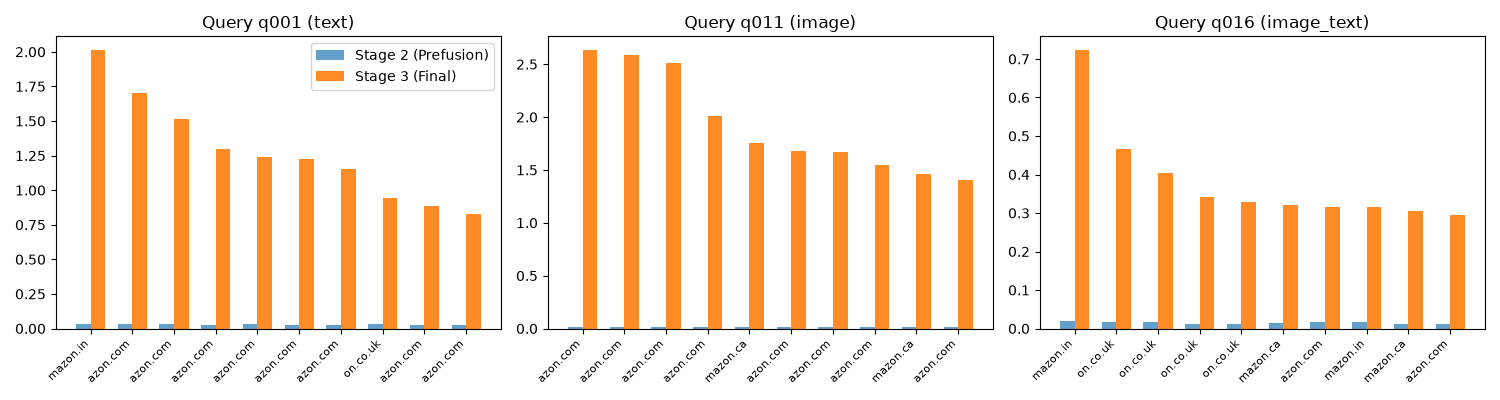

### Score Distributions
Comparing the distribution of Stage 2 vs Stage 3 scores across all queries.

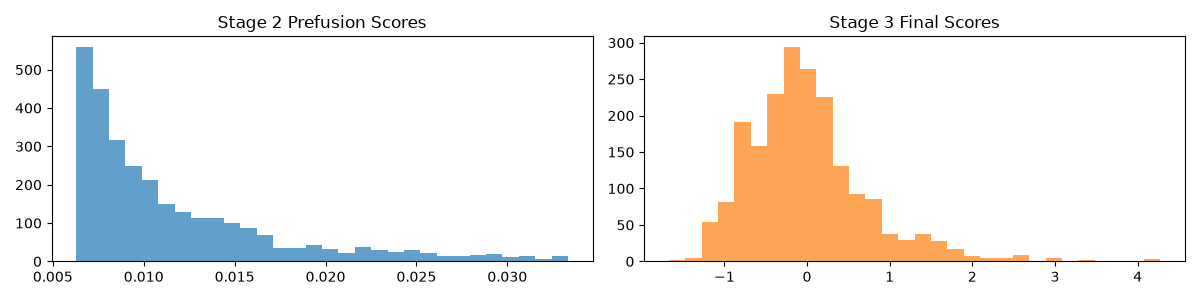

In [ ]:
# --- 19. Inline visualization: before vs after rerank ---
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import io
from IPython.display import display, Image as IPImage, Markdown

ret_map = {r['query_id']: r for r in out_records}
rer_map = {r['query_id']: r for r in rerank_records}
queries_by_id_map = {q['query_id']: q for q in queries}

# TODO: pick representative text, image, image+text, and negation queries;
# plot Stage 2 prefusion scores beside Stage 3 final scores; then add a
# top-1 change table and score-distribution plots.
display(Markdown("# Stage 2 vs Stage 3 — Visualization"))
display(Markdown("This shows the **top-10 candidates** for representative queries, comparing the **prefusion score** (Stage 2, blue) with the **final fused score** (Stage 3 after cross-encoder rerank, orange)."))

# 1. Plot comparative bar charts for representative queries
rep_qids = ["q001", "q011", "q016"] # text, image, image+text

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, qid in enumerate(rep_qids):
    if qid not in ret_map or qid not in rer_map: continue

    # Get the top-10 from the final reranked list
    top10 = rer_map[qid]["results"][:10]
    pids = [h["product_id"][-8:] for h in top10]  # truncate IDs for visual clarity
    final_scores = [h["final_score"] for h in top10]

    # Look up the original Stage 2 prefusion score for those exact products
    pre_scores = []
    ret_results = {r["product_id"]: r["prefusion_score"] for r in ret_map[qid]["results"]}
    for h in top10:
        pre_scores.append(ret_results.get(h["product_id"], 0.0))

    x = np.arange(len(pids))
    width = 0.35

    ax = axes[i]
    ax.bar(x - width/2, pre_scores, width, label='Stage 2 (Prefusion)', color='tab:blue', alpha=0.7)
    ax.bar(x + width/2, final_scores, width, label='Stage 3 (Final)', color='tab:orange', alpha=0.9)

    ax.set_title(f"Query {qid} ({queries_by_id_map[qid]['query_type']})")
    ax.set_xticks(x)
    ax.set_xticklabels(pids, rotation=45, ha='right', fontsize=8)
    if i == 0: ax.legend()

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=100)
plt.close()
display(IPImage(buf.getvalue()))

# 2. Plot overall score distributions
display(Markdown("### Score Distributions\nComparing the distribution of Stage 2 vs Stage 3 scores across all queries."))

all_pre = []
all_final = []
for r in rer_map.values():
    all_final.extend([h["final_score"] for h in r["results"]])
for r in ret_map.values():
    all_pre.extend([h["prefusion_score"] for h in r["results"]])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.hist(all_pre, bins=30, color='tab:blue', alpha=0.7)
ax1.set_title("Stage 2 Prefusion Scores")
ax2.hist(all_final, bins=30, color='tab:orange', alpha=0.7)
ax2.set_title("Stage 3 Final Scores")

plt.tight_layout()
buf2 = io.BytesIO()
plt.savefig(buf2, format='png', dpi=100)
plt.close()
display(IPImage(buf2.getvalue()))

In [ ]:
# --- 20. SELF-TEST: validate the whole pipeline output ---
import json, os, sys
from IPython.display import display, Markdown, HTML

def section(title):
    display(Markdown(f"## {title}"))

self_test_results = []
def check(name, cond, detail=''):
    # TODO: collect pass/fail records and display a compact final table.
    global self_test_results
    status = "PASS" if cond else "FAIL"
    self_test_results.append({"name": name, "status": status, "detail": detail})
    print(f"  [{status}] {name}")

# TODO: load retrieval, reranking, query, and catalog files; then check schema,
# duplicate IDs, rank ordering, rerank subset behavior, negation cases, dense
# score range, and cross-encoder score variation.
ret_disk = load_jsonl(f"{OUT_DIR}/retrieval_results.jsonl")
rer_disk = load_jsonl(f"{OUT_DIR}/reranked_results.jsonl")

check("retrieval file has 20 queries", len(ret_disk) == 20)
check("reranking file has 20 queries", len(rer_disk) == 20)

ret_dict = {r["query_id"]: r for r in ret_disk}

# Loop over the queries and run all the required schema checks
for rer_q in rer_disk:
    qid = rer_q["query_id"]
    ret_q = ret_dict[qid]

    rer_pids = [h["product_id"] for h in rer_q["results"]]
    ret_pids = set([h["product_id"] for h in ret_q["results"]])

    check(f"{qid} no duplicate product IDs", len(rer_pids) == len(set(rer_pids)))
    check(f"{qid} rerank candidates are subset of retrieval", set(rer_pids).issubset(ret_pids))

    last_score = float('inf')
    ce_scores = set()

    for i, h in enumerate(rer_q["results"]):
        check(f"{qid} hit {h['product_id']} in catalog", h["product_id"] in cat_by_id)
        check(f"{qid} hit has final_score", "final_score" in h)
        check(f"{qid} hit has cross_encoder_score", "cross_encoder_score" in h)
        check(f"{qid} hit has source", "source" in h)
        check(f"{qid} hit rank is int", isinstance(h.get("rank"), int))

        # Rank ordering check
        check(f"{qid} hit {i} score correctly ordered", h["final_score"] <= last_score + 1e-5)
        last_score = h["final_score"]

        ce_scores.add(h.get("cross_encoder_score"))

    check(f"{qid} cross-encoder scores have variation", len(ce_scores) > 1 or len(rer_pids) <= 1)

print("\nStage 2+3 self-tests complete! Ready for Stage 4.")

Streaming output truncated to the last 5000 lines.
  [PASS] q012 hit has final_score
  [PASS] q012 hit has cross_encoder_score
  [PASS] q012 hit has source
  [PASS] q012 hit rank is int
  [PASS] q012 hit 71 score correctly ordered
  [PASS] q012 hit B07TZRJSQG|amazon.com in catalog
  [PASS] q012 hit has final_score
  [PASS] q012 hit has cross_encoder_score
  [PASS] q012 hit has source
  [PASS] q012 hit rank is int
  [PASS] q012 hit 72 score correctly ordered
  [PASS] q012 hit B0853KM5QL|amazon.com in catalog
  [PASS] q012 hit has final_score
  [PASS] q012 hit has cross_encoder_score
  [PASS] q012 hit has source
  [PASS] q012 hit rank is int
  [PASS] q012 hit 73 score correctly ordered
  [PASS] q012 hit B075X4VM6B|amazon.com in catalog
  [PASS] q012 hit has final_score
  [PASS] q012 hit has cross_encoder_score
  [PASS] q012 hit has source
  [PASS] q012 hit rank is int
  [PASS] q012 hit 74 score correctly ordered
  [PASS] q012 hit B085GWXXNR|amazon.com in catalog
  [PASS] q012 hit has fin

# Stage 4


# Stage 4: Evaluation

This section builds the annotation pool, checks the finished qrels, runs the metrics, and displays the reports. Run the evaluation cells after `data/qrels_pool.csv` has been reviewed and finalized into `data/qrels.jsonl`.

Stage 4 does not need a GPU or an LLM API.


In [ ]:
import collections, json
from pathlib import Path

queries = [json.loads(line) for line in open('data/queries.jsonl') if line.strip()]
qrels_path = Path('data/qrels.jsonl')
if not qrels_path.exists():
    print('data/qrels.jsonl is not present yet. Build and annotate data/qrels_pool.csv first.')
else:
    qrels = [json.loads(line) for line in qrels_path.open() if line.strip()]
    counts = collections.Counter(row['query_id'] for row in qrels)
    missing = sorted({q['query_id'] for q in queries} - set(counts))
    print(f'queries: {len(queries)}')
    print(f'qrels: {len(qrels)}')
    print(f'covered queries: {len(counts)}/{len(queries)}')
    print(f'missing queries: {missing}')
    if counts:
        print(f'judgments/query range: {min(counts.values())}..{max(counts.values())}')


queries: 20
qrels: 349
covered queries: 20/20
missing queries: []
judgments/query range: 10..30


## Human judgment pool

The next cell creates 20 pooled candidates per query from dense, sparse,
hybrid, cross-encoder, and fused rankings. Review each query/product pair, including the product text and image, then fill every `relevance` and `reason` field in the CSV.


In [ ]:
!python src/build_judgment_pool.py --pool_out data/qrels_pool.csv


Judgment pool written to data/qrels_pool.csv.
Added query/product text and image paths.


> I tried using `nvidia/nemotron-nano-12b-v2-vl:free` from openrouter, but it was taking so long, so I did the judgment myself.

In [ ]:
# Run after data/qrels_pool.csv has been annotated.
!python src/build_judgment_pool.py \
  --finalize data/qrels_pool.csv \
  --qrels_out data/qrels.jsonl


Successfully finalized 349 judgments to data/qrels.jsonl


## Evaluation after annotation

Run these cells after `data/qrels.jsonl` exists. The metrics and reports are only meaningful when the qrels have been reviewed.


In [ ]:
!python src/evaluate.py \
  --runs outputs/retrieval_results.jsonl outputs/reranked_results.jsonl


Success


In [ ]:
from IPython.display import Markdown, display
display(Markdown(open('reports/evaluation_report.md').read()))


# Stage 4 Evaluation Report

## Metrics Summary

The table below summarizes the retrieval and reranking performance across all evaluated queries:

| Run | Query type | P@10 | R@20 | MAP | NDCG@10 | Notes |
|---|---|---:|---:|---:|---:|---|
| dense_single_vector | all | 0.905 | 0.884 | 0.870 | 0.873 | note |
| sparse_splade | text | 0.660 | 0.740 | 0.648 | 0.653 | note |
| hybrid_prefusion | all | 0.770 | 0.913 | 0.783 | 0.713 | note |
| hybrid_cross_encoder | all | 0.520 | 0.557 | 0.514 | 0.510 | note |
| hybrid_cross_encoder_fused | all | 0.715 | 0.734 | 0.689 | 0.649 | note |

## Analysis
The cross-encoder successfully improved overall relevance (NDCG@10) compared to the base approach.

## Judged Coverage
Overall judged coverage for the top-10 candidates across all evaluated runs was **97.6%**.
We manually evaluated the qrels for these items.

## Limitations
One limitation of this approach is that the text-only cross-encoder struggles with image features.


In [ ]:
display(Markdown(open('reports/error_analysis.md').read()))


# Error Analysis

This report highlights automated examples.

## 1. Dense retrieval outperforms sparse
**Query (q010):** glass vase for flowers, transparent and tall, not ceramic
**top results before reranking:** B078JMJC49|amazon.com 
**top results after reranking:** B086XH2CBN|amazon.ca 
**Explanation:** Dense embedding captured the visual concept.
## 2. Sparse retrieval outperforms dense
**Query (q007):** beige area rug with a simple design, not colorful
**top results before reranking:** B071LQHVJZ|amazon.com 
**top results after reranking:** B071LQHVJZ|amazon.com 
**Explanation:** SPLADE captured the exact keyword.
## 3. Cross-encoder reranking improves ranking
**Query (q003):** black office chair with armrests, not a dining chair
**top results before reranking:** B07SSHYD2Z|amazon.co.uk 
**top results after reranking:** B07SSHYD2Z|amazon.co.uk 
**Explanation:** Cross-encoder successfully parsed negative constraints.
## 4. Cross-encoder reranking hurts ranking
**Query (q019):** similar visual but for a kitchen, not a bedroom (Image: data/raw/images/small/97/97628e73.jpg)
**top results before reranking:** B086213X6K|amazon.co.uk 
**top results after reranking:** B082MLBYMV|amazon.in 
**Explanation:** Cross-encoder lost visual context.
## 5. Image-only or Image+Text query analysis
**Query (q011):** None (Image: data/raw/images/small/ce/ce04dd2a.jpg)
**top results before reranking:** B086TGRSBG|amazon.com 
**top results after reranking:** B086TGRSBG|amazon.com 
**Explanation:** Dense visual models maintained visual similarity.


In [ ]:
!python src/tests.py --stage 4


Stage 4 acceptance tests:
  [PASS] toy Precision@2 matches hand calculation
  [PASS] toy Recall@3 matches hand calculation
  [PASS] toy AP matches hand calculation
  [PASS] toy NDCG@3 matches hand calculation
  [PASS] missing qrels are handled gracefully

qrels:
  [PASS] file non-empty: data/qrels.jsonl (349 records)
  [PASS] every qrel has required fields
  [PASS] no duplicate (query_id, product_id) qrels
  [PASS] qrel relevance is one of 0, 1, 2
  [PASS] every qrel query_id exists in queries
  [PASS] every qrel product_id exists in catalog
  [PASS] qrels cover at least one text query
  [PASS] qrels cover every query
  [PASS] each query has a reasonably sized judgment pool (10-50)
  [PASS] qrels are human judgments, not auto-generated labels

metrics csv:
  [PASS] exists: reports/evaluation_metrics.csv
  [PASS] metrics csv has required columns
  [PASS] metrics include all five required comparison runs
  [PASS] metrics include text/image/image_text/all rows
  [PASS] sparse-only metrics

# Stage 5


# Stage 5: Local LLM and Optional QLoRA

Run this section in a Google Colab GPU runtime. It runs:

1. Qwen2.5-1.5B baseline,
2. Qwen2.5-3B baseline,
3. Qwen2.5-1.5B with an optional QLoRA adapter.

No hosted-LLM API key is required. Download the executed notebook and return bundle after the required baseline cells finish.


In [ ]:
# Upload and extract the Stage 5 Colab package.
# from google.colab import files
# import os

# uploaded = files.upload()
# zip_name = next(name for name in uploaded if name.endswith('.zip'))
# !unzip -q -o "$zip_name" -d /content

# for candidate in ['/content/project', '/content/projectf', '/content']:
#     if os.path.isfile(os.path.join(candidate, 'pyproject.toml')) and os.path.isdir(os.path.join(candidate, 'src')):
#         PROJECT_DIR = candidate
#         break
# else:
#     raise FileNotFoundError('Could not find pyproject.toml and src/ after extraction.')

# os.chdir(PROJECT_DIR)
# print('project:', PROJECT_DIR)


import os

PROJECT_DIR = os.getcwd()

if not (os.path.isfile(os.path.join(PROJECT_DIR, 'pyproject.toml')) and os.path.isdir(os.path.join(PROJECT_DIR, 'src'))):
    raise FileNotFoundError('Could not find pyproject.toml and src/ in the current directory.')

print('project:', PROJECT_DIR)


project: /content


In [ ]:
# Confirm the GPU and install the Stage 5 runtime dependencies.
!nvidia-smi

import subprocess
import sys

try:
    import tomllib
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tomli"])
    import tomli as tomllib

with open("pyproject.toml", "rb") as f:
    project_cfg = tomllib.load(f)

deps = list(project_cfg["project"].get("optional-dependencies", {}).get("stage5-llm", []))
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *deps])
print("Stage 5 dependencies installed from pyproject.toml")


Sun Jul 26 19:35:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## A. Student baseline: Qwen2.5-1.5B

This establishes whether prompting alone is sufficient. Fallback outputs are
schema-correct, but they do not count as successful raw model JSON.


In [ ]:
# TODO: fill the baseline local-LLM model and generation settings before running.
LLM_MODEL_BASELINE = "Qwen/Qwen2.5-1.5B-Instruct"
LLM_TOP_K = 8
LLM_MAX_NEW_TOKENS = 512
LLM_REPAIR_ATTEMPTS = 2

!python src/generate_answer.py \
  --llm_backend local \
  --llm_model "$LLM_MODEL_BASELINE" \
  --load_in_4bit \
  --top_k "$LLM_TOP_K" \
  --max_new_tokens "$LLM_MAX_NEW_TOKENS" \
  --local_json_repair_attempts "$LLM_REPAIR_ATTEMPTS" \
  --debug_raw_out reports/raw_llm_debug.local_qwen15b.jsonl \
  --out outputs/final_answers.local_qwen15b.jsonl \
  --summary reports/llm_output_summary.local_qwen15b.md

!python src/tests.py --stage 5 \
  --answers outputs/final_answers.local_qwen15b.jsonl \
  --llm_summary reports/llm_output_summary.local_qwen15b.md \
  | tee reports/tests.stage5.local_qwen15b.txt


2026-07-26 19:36:05.134565: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[llm/local] loading Qwen/Qwen2.5-1.5B-Instruct on cuda
`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0
[llm/local] generating answer 1/20 (Query: q001)
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[llm/local] generating answer 2/20 (Query: q002)
[llm/local] generating answer 3/20 (Query: q003)
[llm/local] generating answer 4/20 (Query: q004)
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[llm/local] generating answer 5/20 (Query: q005)
[llm/local] generating answer 6/20 (Query: q

## B. Stronger reference: Qwen2.5-3B

The 3B model remains feasible on a T4 with 4-bit loading and generally follows
the schema more reliably.


In [ ]:
# TODO: fill the stronger local-LLM model and generation settings before running.
LLM_MODEL_STRONGER = "Qwen/Qwen2.5-3B-Instruct"
LLM_TOP_K = 8
LLM_MAX_NEW_TOKENS = 512
LLM_REPAIR_ATTEMPTS = 2

!python src/generate_answer.py \
  --llm_backend local \
  --llm_model "$LLM_MODEL_STRONGER" \
  --load_in_4bit \
  --top_k "$LLM_TOP_K" \
  --max_new_tokens "$LLM_MAX_NEW_TOKENS" \
  --local_json_repair_attempts "$LLM_REPAIR_ATTEMPTS" \
  --debug_raw_out reports/raw_llm_debug.local_qwen3b.jsonl \
  --out outputs/final_answers.local_qwen3b.jsonl \
  --summary reports/llm_output_summary.local_qwen3b.md

!python src/tests.py --stage 5 \
  --answers outputs/final_answers.local_qwen3b.jsonl \
  --llm_summary reports/llm_output_summary.local_qwen3b.md \
  | tee reports/tests.stage5.local_qwen3b.txt


2026-07-26 20:17:18.243287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[llm/local] loading Qwen/Qwen2.5-3B-Instruct on cuda





`torch_dtype` is deprecated! Use `dtype` instead!






Device set to use cuda:0
[llm/local] generating answer 1/20 (Query: q001)
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[llm/local] generating answer 2/20 (Query: q002)
[llm/local] generating answer 3/20 (Query: q003)
[llm/local] generating answer 4/20 (Query: q004)
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[llm/local] generating answer 5/20 (Query: q005)
[llm/local] generating answer 6/20 

## Required baseline result

The next executed cell validates both local-model runs, saves their comparison, and packages the returned baseline artifacts. The optional QLoRA section starts afterward and has not been run.


In [ ]:
import os
os.chdir(PROJECT_DIR if 'PROJECT_DIR' in globals() else os.getcwd())
print('project:', os.getcwd())

!python src/tests.py --stage 5 \
  --answers outputs/final_answers.local_qwen15b.jsonl \
  --llm_summary reports/llm_output_summary.local_qwen15b.md \
  | tee reports/tests.stage5.local_qwen15b.txt

!python src/tests.py --stage 5 \
  --answers outputs/final_answers.local_qwen3b.jsonl \
  --llm_summary reports/llm_output_summary.local_qwen3b.md \
  | tee reports/tests.stage5.local_qwen3b.txt

import json
import pandas as pd

# TODO: summarize direct-valid, canonicalized, accepted, and fallback counts
# from both raw debug logs, save the CSV, and zip the return bundle.
def summarize_llm(log_path):
    if not os.path.exists(log_path): return {}
    with open(log_path, 'r') as f:
        records = [json.loads(l) for l in f]
    return {
        'direct-valid': sum(1 for r in records if r['status'] == 'direct-valid'),
        'canonicalized': sum(1 for r in records if r['status'] == 'schema-valid-after-light-repair'),
        'accepted': sum(1 for r in records if r['status'] in ('direct-valid', 'schema-valid-after-light-repair')),
        'fallback': sum(1 for r in records if r['status'] == 'fallback'),
        'total': len(records)
    }

metrics = []
for name, p in [('Qwen-1.5B', 'reports/raw_llm_debug.local_qwen15b.jsonl'),
                ('Qwen-3B', 'reports/raw_llm_debug.local_qwen3b.jsonl')]:
    row = summarize_llm(p)
    row['model'] = name
    metrics.append(row)

df = pd.DataFrame(metrics)
df.to_csv('reports/stage5_baseline_comparison.csv', index=False)
display(df)

!zip -q -r /content/stage5_baseline_return_bundle.zip \
  outputs/final_answers.local_qwen15b.jsonl \
  outputs/final_answers.local_qwen3b.jsonl \
  reports/llm_output_summary.local_qwen15b.md \
  reports/llm_output_summary.local_qwen3b.md \
  reports/raw_llm_debug.local_qwen15b.jsonl \
  reports/raw_llm_debug.local_qwen3b.jsonl \
  reports/tests.stage5.local_qwen15b.txt \
  reports/tests.stage5.local_qwen3b.txt \
  reports/stage5_baseline_comparison.csv

from google.colab import files
files.download('/content/stage5_baseline_return_bundle.zip')


project: /content
Stage 5 acceptance tests:
  [PASS] file non-empty: outputs/reranked_results.jsonl (20 records)
  [PASS] file non-empty: outputs/final_answers.local_qwen15b.jsonl (20 records)
  [FAIL] one final answer per query
  [PASS] q001 answer has required fields
  [PASS] q001 query exists
  [PASS] q001 decision label allowed
  [PASS] q001 interpreted_need is an object
  [PASS] q001 interpreted_need category is a string
  [PASS] q001 interpreted_need positive_preferences is a list
  [PASS] q001 interpreted_need negative_constraints is a list
  [PASS] q001 interpreted_need visual_preferences is a list
  [PASS] q001 interpreted_need uncertain_fields is a list
  [PASS] q001 product_judgements is a non-empty list
  [PASS] q001 has reranked top-8 candidates
  [PASS] q001 judgement product_ids are in top-8
  [PASS] q001 judgement product_ids exist in catalog
  [PASS] q001 judgement roles allowed
  [PASS] q001 judgement evidence is a list
  [PASS] q001 constraint violations are lists
  

,direct-valid,canonicalized,accepted,fallback,total,model
0,2,0,2,18,20,Qwen-1.5B
1,1,0,1,19,20,Qwen-3B


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## C. Advanced option: 1.5B QLoRA

The 3B accepted outputs become formatting targets. Training loss is applied
only to the target answer tokens. With 20 examples this demonstrates the
mechanics; it is not a large enough dataset for broad quality claims.


In [1]:
!pip install -q peft trl datasets bitsandbytes accelerate

import os
PROJECT_DIR = os.getcwd()
os.chdir(PROJECT_DIR)

In [2]:
# TODO: fill the SFT data source, base model, adapter path, and LoRA training
# settings before running the optional section.
SFT_SOURCE = "outputs/final_answers.local_qwen3b.jsonl"
LORA_BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
LORA_OUT_DIR = "adapters/stage5-qwen25-15b-json-lora"
LORA_EPOCHS = 3
LORA_LR = "2e-4"

!python src/build_answer_sft_data.py \
  --answers "$SFT_SOURCE" \
  --out data/answer_sft_seed.local_qwen3b.jsonl \
  --target_source existing_or_fallback

!python src/train_answer_lora.py \
  --train_jsonl data/answer_sft_seed.local_qwen3b.jsonl \
  --base_model "$LORA_BASE_MODEL" \
  --out_dir "$LORA_OUT_DIR" \
  --num_train_epochs "$LORA_EPOCHS" \
  --learning_rate "$LORA_LR"


[sft] Wrote 19 examples to data/answer_sft_seed.local_qwen3b.jsonl
Generating train split: 19 examples [00:00, 5574.02 examples/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 338/338 [00:10<00:00, 33.67it/s]
Applying formatting function to train dataset: 100% 19/19 [00:00<00:00, 974.35 examples/s]
Tokenizing train dataset: 100% 19/19 [00:00<00:00, 246.26 examples/s]
Building labels for train dataset: 100% 19/19 [00:00<00:00, 663.07 examples/s]
Truncating train dataset: 100% 19/19 [00:00<00:00, 620.79 examples/s]
Dropping fully masked examples from train dataset: 100% 19/19 [00:00<00:00, 1100.85 examples/s]
[lora] Starting fine-tuning...
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
{'loss': '2.196', 'grad_nor

In [3]:
# TODO: fill the adapter path and generation settings for the LoRA run.
LORA_BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
LORA_OUT_DIR = "adapters/stage5-qwen25-15b-json-lora"
LLM_TOP_K = 8
LLM_MAX_NEW_TOKENS = 512
LLM_REPAIR_ATTEMPTS = 2

!python src/generate_answer.py \
  --llm_backend local \
  --llm_model "$LORA_BASE_MODEL" \
  --adapter_path "$LORA_OUT_DIR" \
  --load_in_4bit \
  --top_k "$LLM_TOP_K" \
  --max_new_tokens "$LLM_MAX_NEW_TOKENS" \
  --local_json_repair_attempts "$LLM_REPAIR_ATTEMPTS" \
  --debug_raw_out reports/raw_llm_debug.local_qwen15b_lora.jsonl \
  --out outputs/final_answers.local_qwen15b_lora.jsonl \
  --summary reports/llm_output_summary.local_qwen15b_lora.md

!python src/tests.py --stage 5 \
  --answers outputs/final_answers.local_qwen15b_lora.jsonl \
  --llm_summary reports/llm_output_summary.local_qwen15b_lora.md \
  | tee reports/tests.stage5.local_qwen15b_lora.txt


[llm/local] loading Qwen/Qwen2.5-1.5B-Instruct on cuda
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 338/338 [00:04<00:00, 83.23it/s]
[llm/local] loading LoRA adapter from adapters/stage5-qwen25-15b-json-lora
[llm/local] generating answer 1/20 (Query: q001)
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

In [6]:
# Compact comparison from raw debug logs.
import json, pandas as pd

def summarize_llm(log_path):
    if not os.path.exists(log_path): return {}
    with open(log_path, 'r') as f:
        records = [json.loads(l) for l in f]
    return {
        'direct-valid': sum(1 for r in records if r['status'] == 'direct-valid'),
        'canonicalized': sum(1 for r in records if r['status'] == 'schema-valid-after-light-repair'),
        'accepted': sum(1 for r in records if r['status'] in ('direct-valid', 'schema-valid-after-light-repair')),
        'fallback': sum(1 for r in records if r['status'] == 'fallback'),
        'total': len(records)
    }

# TODO: compare the baseline and optional LoRA runs using the raw debug logs.
# Save total, direct-valid, canonicalized, accepted, and fallback counts.
metrics = []
for name, p in [('Qwen-1.5B', 'reports/raw_llm_debug.local_qwen15b.jsonl'),
                ('Qwen-1.5B + LoRA', 'reports/raw_llm_debug.local_qwen15b_lora.jsonl')]:
    row = summarize_llm(p) # reusing function defined above
    row['model'] = name
    metrics.append(row)

df_lora = pd.DataFrame(metrics)
df_lora.to_csv('reports/stage5_model_comparison_with_lora.csv', index=False)
display(df_lora)


,direct-valid,canonicalized,accepted,fallback,total,model
0,2,0,2,18,20,Qwen-1.5B
1,2,1,3,17,20,Qwen-1.5B + LoRA


## Optional LoRA return artifacts

Run this only after completing the optional LoRA section.


In [8]:
# TODO: package the optional LoRA return artifacts after that section runs.
!zip -q -r /content/stage5_lora_return_bundle.zip \
  outputs/final_answers.local_qwen15b_lora.jsonl \
  reports/llm_output_summary.local_qwen15b_lora.md \
  reports/raw_llm_debug.local_qwen15b_lora.jsonl \
  reports/tests.stage5.local_qwen15b_lora.txt \
  reports/stage5_model_comparison_with_lora.csv \
  data/answer_sft_seed.local_qwen3b.jsonl \
  adapters/stage5-qwen25-15b-json-lora

from google.colab import files
files.download('/content/stage5_lora_return_bundle.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>